## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from rapidfuzz import process

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scipy import stats

## 1. Data Loading

- First, we upload the Excel file with 3 sheets
- Second, we extract the sheets into separate dataframes:
  - `df_species` corresponds to the ESPECES sheet
  - `df_gps` corresponds to the GPS-MILIEU sheet
  - `df_obs` corresponds to the NOM Français sheet, which contains the observations (hence the name df_obs)

In [2]:
file_path = "../data/raw/Observations 2012-2025.xlsx"
#retrieve the number of sheets
print("number of sheets:", pd.ExcelFile(file_path).sheet_names)

df_species = pd.read_excel(file_path, sheet_name='ESPECES', header=None, usecols=[2, 3, 4])
df_species.columns = ['french_name', 'scientific_name', 'status']
# df_species.isna().sum()
# status has a missing value
df_species.head()

df_gps = pd.read_excel(file_path, sheet_name='GPS-MILIEU', header=1, usecols=[2, 3, 4, 5, 6, 7])
df_gps.columns = ['transect', 'X', 'Y', 'habitat', 'transect_id', 'point_id']
# df_gps.isna().sum()
# 0 missing values
df_gps.head()

df_obs = pd.read_excel(file_path, sheet_name='NOM FRANÇAIS', skiprows=[0, 1], header=0)
df_obs.columns = [
        'observer',              # Observer name
        'dept_code',             # Department code  
        'transect',              # Transect name
        'date',                  # Date
        'visit_number',          # 1st, 2nd or 3rd visit
        'clouds',                # Cloud cover
        'rain',                  # Rain intensity
        'wind',                  # Wind strength
        'visibility',            # Visibility
        'point',                 # Point number
        'start_time',            # Start time
        'species',               # Species name
        
        # Contact distances
        'auditory_0_25m',       
        'visual_0_25m',        
        'auditory_25_50m',       
        'visual_25_50m',   
        'auditory_50_100m', 
        'visual_50_100m',     
        'auditory_100m_plus', 
        'visual_100m_plus',   
        
        # Flight
        'flight',
        
        # Totals (4 columns)
        'auditory_total',   
        'visual__no_flight_total',         
        'auditory_visual_no_flight_total',
        'auditory_visual_with_flight_total',
        
        #Notes
        'Notes'
]
df_obs['date'] = pd.to_datetime(df_obs['date'])
df_obs.head()

number of sheets: ['ESPECES', 'GPS-MILIEU', 'NOM FRANÇAIS']


,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,auditory_50_100m,visual_50_100m,auditory_100m_plus,visual_100m_plus,flight,auditory_total,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes
0,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN
1,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1,1.0,NaN
2,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,0.0,2.0,2,2.0,NaN
3,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN
4,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN


## 2. Data coherence   

In [3]:
def spelling_correction(df_source, df_reference, column_name, similarity_threshold=90):
    """
    Corrects spelling variations in a column by matching against a reference dataframe.
    
    Parameters:
    -----------
    df_source : pd.DataFrame
        The dataframe containing values that need correction
    df_reference : pd.DataFrame
        The dataframe containing the reference/correct values
    column_name : str
        The name of the column to correct in both dataframes
    similarity_threshold : int, optional (default=90)
        Minimum similarity score (0-100) to consider a match. 
        100 = exact match, 90+ = probable match
    
    Returns:
    --------
    dict
        Mapping of original values to corrected values
    """
    df_source[column_name] = df_source[column_name].str.strip().str.lower()
    df_reference[column_name] = df_reference[column_name].str.strip().str.lower()
    
    source_values = df_source[column_name].unique()
    reference_values = df_reference[column_name].unique()

    mapping = {}
    for source_val in source_values:
        match, score, _ = process.extractOne(source_val, reference_values) #Based on levenshtein's distance
        if similarity_threshold <= score < 100:
            mapping[source_val] = match
            print(f"Correction: '{source_val}' -> '{match}' (score={score})")

    # Apply corrections
    df_source[column_name] = df_source[column_name].replace(mapping)
    return mapping


def check_coherence(df_species, df_gps, df_obs): 
    obs_transects = set(df_obs['transect'].str.strip().str.lower().unique())
    gps_transects = set(df_gps['transect'].str.strip().str.lower().unique())
    
    missing_transects = obs_transects - gps_transects
    
    if missing_transects:
        print("Transects in observations but not in GPS data:")
        for transect in sorted(missing_transects):
            print(f"  - {transect}")
        # Correction of the spelling errors
        transect_mapping = spelling_correction(df_obs, df_gps, 'transect', similarity_threshold=90)
    else:
        print("All observation transects have corresponding GPS data")
    
    
#df_species_cp = df_species.copy() 
#df_gps_cp = df_gps.copy() 
#df_obs_cp = df_obs.copy()
check_coherence(df_species, df_gps, df_obs)
check_coherence(df_species, df_gps, df_obs)

Transects in observations but not in GPS data:
  - desmarinière
Correction: 'desmarinière' -> 'desmarinières' (score=96.0)
All observation transects have corresponding GPS data


In [4]:
df_obs_merged = df_obs.merge(
        df_species, 
        left_on='species', 
        right_on='french_name', 
        how='left',
        suffixes=('', '_species')
    )
#transect_habitat = df_gps.groupby('transect')['habitat'].first().reset_index()
#df_full = df_obs_merged.merge(
#     transect_habitat,
#     on='transect',
#     how='left'
#)
#Un transect peut avoir plusieurs habitats selon les points, on merge donc avec les points

# Extraire le numéro après le P
#df_gps['point'] = df_gps['point_id'].str.extract(r'P(\d+)')[0]
#missing_points = df_gps[df_gps['point'].isna()]
#print(missing_points)

df_gps['point_id'] = df_gps['point_id'].replace('SIPI', 'S1P1')

df_gps['point'] = df_gps['point_id'].str.extract(r'P(\d+)')[0].astype(int)
df_obs['point'] = df_obs['point'].astype(int)

df_full = df_obs_merged.merge(
    df_gps[['transect', 'point', 'X', 'Y', 'habitat']],
    on=['transect', 'point'],
    how='left'
)

## 2. Dataset Structure

In [5]:
# Table dimensions
print("="*60)
print("TABLE DIMENSIONS")
print("="*60)

print(f"\n1. SPECIES table:")
print(f"   - {len(df_species)} species")
print(f"   - {df_species['status'].nunique()} status categories")

print(f"\n2. GPS-MILIEU table:")
print(f"   - {len(df_gps)} observation points")
print(f"   - {df_gps['transect'].nunique()} transects")
print(f"   - {df_gps['habitat'].nunique()} habitat types")

print(f"\n3. OBSERVATIONS table:")
print(f"   - {len(df_obs):,} raw observations")
print(f"   - {len(df_full):,} enriched observations")
print(f"   - {df_full.shape[1]} columns")

TABLE DIMENSIONS

1. SPECIES table:
   - 87 species
   - 8 status categories

2. GPS-MILIEU table:
   - 650 observation points
   - 65 transects
   - 7 habitat types

3. OBSERVATIONS table:
   - 114,495 raw observations
   - 115,304 enriched observations
   - 32 columns


## DATA CLEANUP

In [6]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115304 entries, 0 to 115303
Data columns (total 32 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   observer                           115304 non-null  object        
 1   dept_code                          115302 non-null  float64       
 2   transect                           115304 non-null  object        
 3   date                               115304 non-null  datetime64[ns]
 4   visit_number                       115304 non-null  int64         
 5   clouds                             115303 non-null  object        
 6   rain                               115303 non-null  float64       
 7   wind                               115287 non-null  float64       
 8   visibility                         115303 non-null  float64       
 9   point                              115304 non-null  int64         
 10  start_time          

#### Species Names
We remove rows where the species is unknown, as species identification is what we aim to predict. Therefore, we cannot replace these missing values—doing so would defeat the purpose of building our predictive model.

#### Species Status
We notice that the bird species 'Astrild à joues orange' is missing its status. Since this study was conducted in Martinique and Guadeloupe (department codes 971 and 972), and knowing that this specific bird is African by origin, we can directly deduce that it is "Exogène introduit par l'homme" in our dataset.

In [7]:
#Drop si on ne sait pas ce qui a été observé
df_full = df_full.dropna(subset=['french_name', 'scientific_name'], how='all')

# Set a status for 'Astrild à joues orange'
df_full.loc[df_full['french_name'] == "Astrild à joues orange", 'status'] = 'Exogène introduit par l\'homme'

#### Replace NaN Departments

Replace all NaN department values with the department number of their corresponding transect, since each transect is located in only one department (IN OUR DATASET, thanks to the assertion below).

In [8]:
for transect in df_full[df_full['dept_code'].isna()]['transect']:
    # Get the unique non null dept_code for this transect
    unique_dept = df_full[df_full['transect'] == transect]['dept_code'].dropna().unique()
    
    # Assert there's exactly one unique dept_code per transect
    assert len(unique_dept) == 1, f"Expected 1 unique dept_code for transect '{transect}', but found {len(unique_dept)}: {unique_dept}"
    
    # Fill NaN values with this dept_code
    df_full.loc[df_full['transect'] == transect, 'dept_code'] = df_full.loc[df_full['transect'] == transect, 'dept_code'].fillna(unique_dept[0])

In [9]:
# Remplacer les valeurs manquantes dans clouds, rain, wind, visibility (itératif avec RandomForest)

cols_to_impute = ['clouds', 'rain', 'wind', 'visibility']

for c in cols_to_impute:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')


# Si TOUTES les variables météo sont manquantes pour une ligne → on met tout à 0
mask_all_nan = df_full[cols_to_impute].isna().all(axis=1)
df_full.loc[mask_all_nan, cols_to_impute] = 0

# Sinon, on peut faire une imputation plus fine pour les lignes partiellement manquantes
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    max_iter=10,
    random_state=42
)

df_full.loc[~mask_all_nan, cols_to_impute] = imputer.fit_transform(
    df_full.loc[~mask_all_nan, cols_to_impute]
)

print(df_full[cols_to_impute].isna().sum())

df_full

clouds        0
rain          0
wind          0
visibility    0
dtype: int64


,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes,french_name,scientific_name,status,X,Y,habitat
0,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,706274,1624126,Forêt humide
1,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,1.0,1,1.0,NaN,Sporophile cici,Melanospiza bicolor ou Tiaris bicolor,Autochtone,706274,1624126,Forêt humide
2,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,2.0,2,2.0,NaN,Colibri falle-vert,Eulampis h. holosericeus,Endémique des Petites Antilles,706274,1624126,Forêt humide
3,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Elénie siffleuse,Elaenia m. martinica,Autochtone,706274,1624126,Forêt humide
4,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Coulicou manioc,Coccyzus minor,Autochtone,706274,1624126,Forêt humide
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115299,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,2,2.0,NaN,Sporophile rougegorge,Loxigilla n. noctis,Endémique des Petites Antilles,708778,1621356,Périurbain
115300,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,1,1.0,NaN,Saltator gros-bec,Saltator a. albicollis,Autochtone,708778,1621356,Périurbain
115301,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,2,2.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,708778,1621356,Périurbain
115302,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,3,3.0,NaN,Viréo à moustaches,Vireo altiloquus barbadensis,Autochtone,708778,1621356,Périurbain


In [10]:
# remplacer les valeurs manquantes dans les colonnes de comptage par 0 + recalcul des totaux

auditory_cols = ['auditory_0_25m', 'auditory_25_50m', 'auditory_50_100m', 'auditory_100m_plus']
visual_cols = ['visual_0_25m', 'visual_25_50m', 'visual_50_100m', 'visual_100m_plus']
flight = ['flight']
for c in auditory_cols + visual_cols + flight:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')
    
df_full[ auditory_cols + visual_cols + flight] = df_full[ auditory_cols + visual_cols + flight].fillna(0)

df_full.head()

totals = ['auditory_total', 'visual__no_flight_total', 'auditory_visual_no_flight_total', 'auditory_visual_with_flight_total']
for c in totals:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')
    
df_full['auditory_total'] = df_full[auditory_cols].sum(axis=1)
df_full['visual__no_flight_total'] = df_full[visual_cols].sum(axis=1)
df_full['auditory_visual_no_flight_total'] = df_full[auditory_cols + visual_cols].sum(axis=1)
df_full['auditory_visual_with_flight_total'] = df_full[auditory_cols + visual_cols + ['flight']].sum(axis=1)

In [11]:
nan_cols = df_full.columns[df_full.isna().any()]
print(df_full[nan_cols].isna().sum())

Notes    103212
dtype: int64


In [12]:
df_full.columns

Index(['observer', 'dept_code', 'transect', 'date', 'visit_number', 'clouds',
       'rain', 'wind', 'visibility', 'point', 'start_time', 'species',
       'auditory_0_25m', 'visual_0_25m', 'auditory_25_50m', 'visual_25_50m',
       'auditory_50_100m', 'visual_50_100m', 'auditory_100m_plus',
       'visual_100m_plus', 'flight', 'auditory_total',
       'visual__no_flight_total', 'auditory_visual_no_flight_total',
       'auditory_visual_with_flight_total', 'Notes', 'french_name',
       'scientific_name', 'status', 'X', 'Y', 'habitat'],
      dtype='object')

In [13]:
nan_cols = df_full.columns[df_full.isna().any()]
print(df_full[nan_cols].isna().sum())

Notes    103212
dtype: int64


In [14]:
df_full['Notes'].unique()


array([nan, 'en formation  SOPHIE Stéphane/ ELY-MARIUS Séverine',
       'Compagnonnage par Beatriz Conde  ', 'Banane 100% coupé',
       "Beaucoup d'ordure et carcasse de voiture",
       'Camping de plusiers personnes sur ce site',
       'Végetation très secs', 'COMPAGNONNAGE PAR BEATRIZ CONDE',
       'CARCASSE DE VOITURE',
       'Les PRODOM ont trouvé un nouveau site de nidification la toiture du lycée',
       'Canne 100% coupé', 'Canne 70% coupé', "Aménagement d'un parking",
       'DORTOIRE', 'Canne à sucre  100% coupé', 'Canne à sucre 50% coupé',
       'FAIT PAR BEATRIZ CONDE', "Accompagner par Caroll-Ann' Portel",
       'AU NID',
       'Oiseau dans la peripherie du camps de canne- Canne a sucre basse',
       'Canne basse', 'Sans canne 50% et canne à sucre basse 50%',
       'Pas de canne', 'Bassin de traitement',
       'COMPAGNONAGE AVEC B.CONDE', "SUR L'ILET BOISSEAU",
       "Presence d'iguane", 'Compagnonnage par Beatriz CONDE',
       'COMPAGNONNAGE PAR BEATRIZ COND

## Clustering : Regroupons les espèces qui ont des profils similaires de détection et d’habitat.

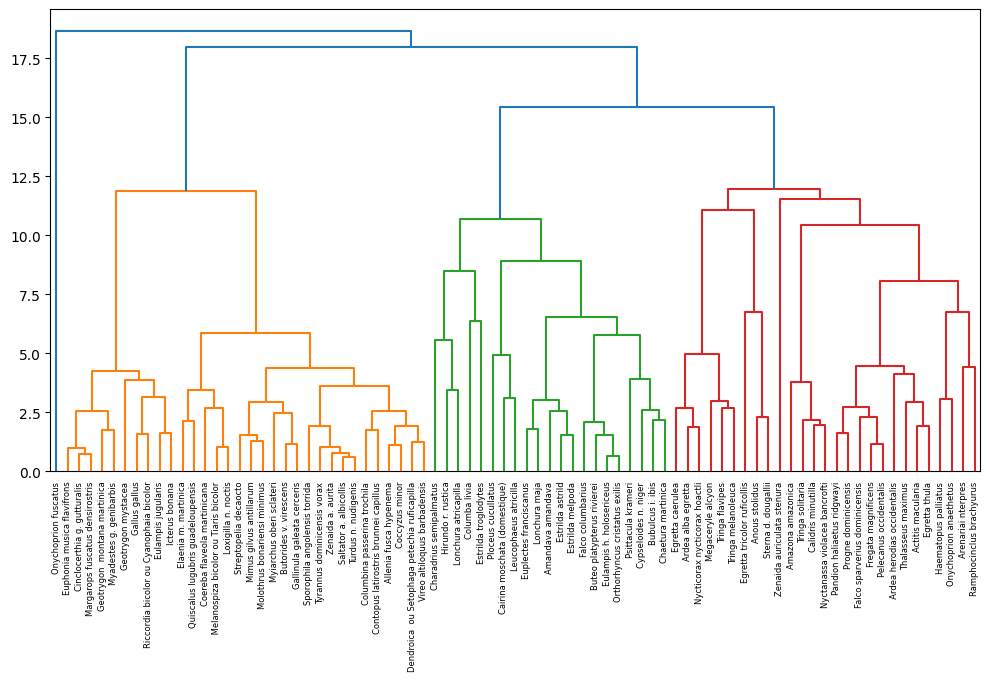

In [15]:
detection_cols = [
    'auditory_0_25m', 'auditory_25_50m', 'auditory_50_100m', 'auditory_100m_plus',
    'visual_0_25m', 'visual_25_50m', 'visual_50_100m', 'visual_100m_plus',
    'flight'
]

habitat_dummies = pd.get_dummies(df_full['habitat'], prefix='habitat')
df_cluster = pd.concat([df_full[detection_cols], habitat_dummies], axis=1)

df_species_cluster = df_cluster.groupby(df_full['scientific_name']).mean()



scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_species_cluster)

Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df_species_cluster.index, leaf_rotation=90)
plt.show()

c:\Users\AMINE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\AMINE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\AMINE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\AMINE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\clus

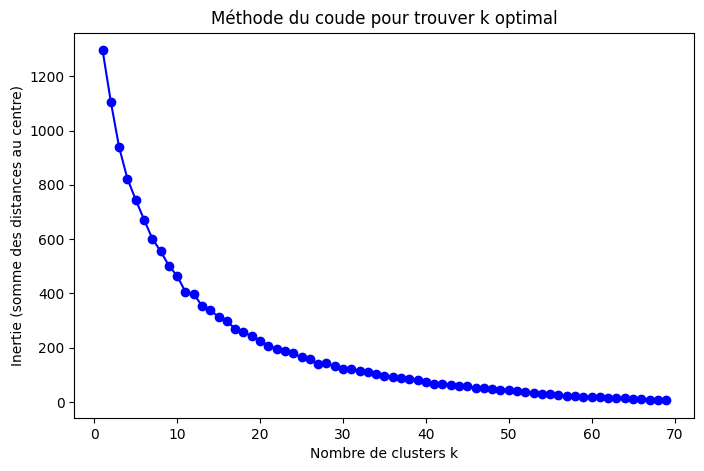

In [16]:
inertia = []
K = range(1, 70)  # tester de 1 à 14 clusters
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances au centre)')
plt.title('Méthode du coude pour trouver k optimal')
plt.show()


c:\Users\AMINE\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\AMINE\AppData\Local\Temp\ipykernel_18052\3647295126.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', n_clusters)  # 'tab20' permet plus de couleurs, interpolé si >20


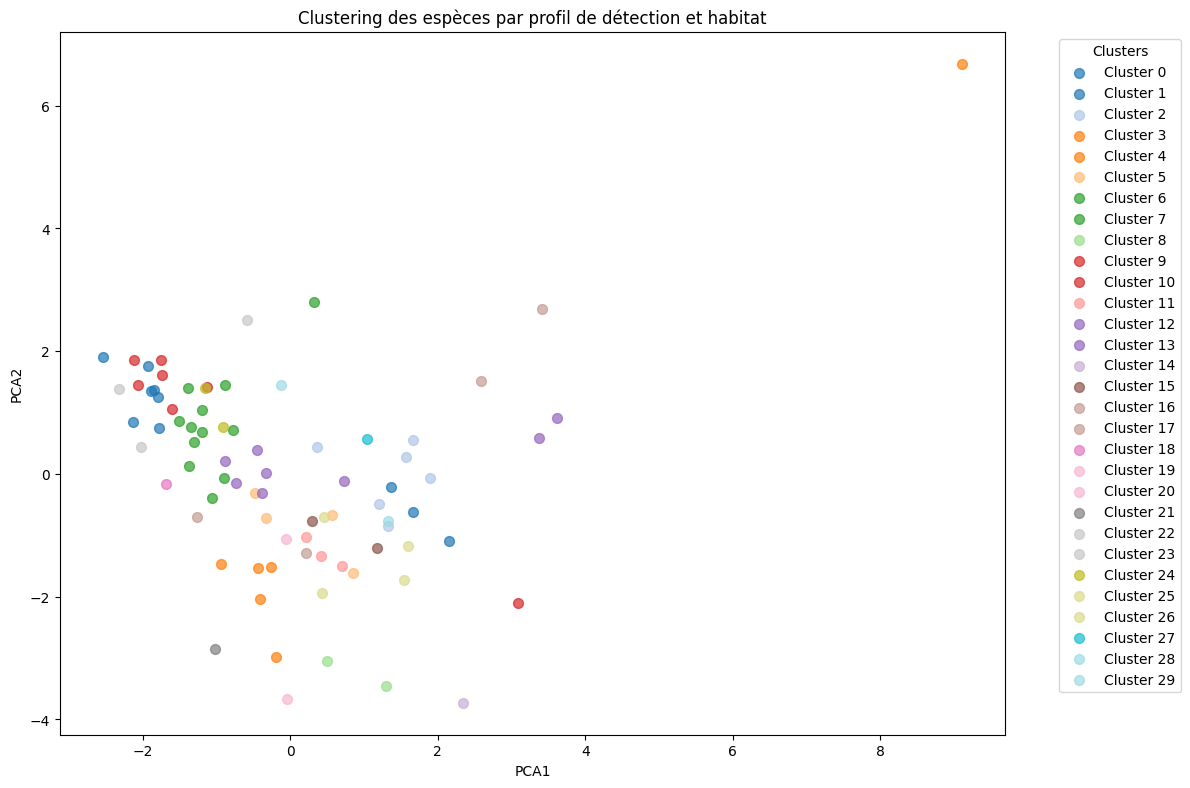

In [17]:
# Réduction à 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=30, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12,8))

n_clusters = len(np.unique(clusters))
# Palette de couleurs continue
colors = cm.get_cmap('tab20', n_clusters)  # 'tab20' permet plus de couleurs, interpolé si >20

for cluster_id in range(n_clusters):
    mask = clusters == cluster_id
    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        color=colors(cluster_id),
        label=f'Cluster {cluster_id}',
        s=50, alpha=0.7
    )

plt.xlabel('PCA1')
plt.ylabel('PCA2')
#for i, name in enumerate(df_species_cluster.index):
#    plt.text(X_pca[i,0], X_pca[i,1], name, fontsize=8)
plt.title('Clustering des espèces par profil de détection et habitat')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')  # légende à droite
plt.tight_layout()
plt.show()


## Cartes

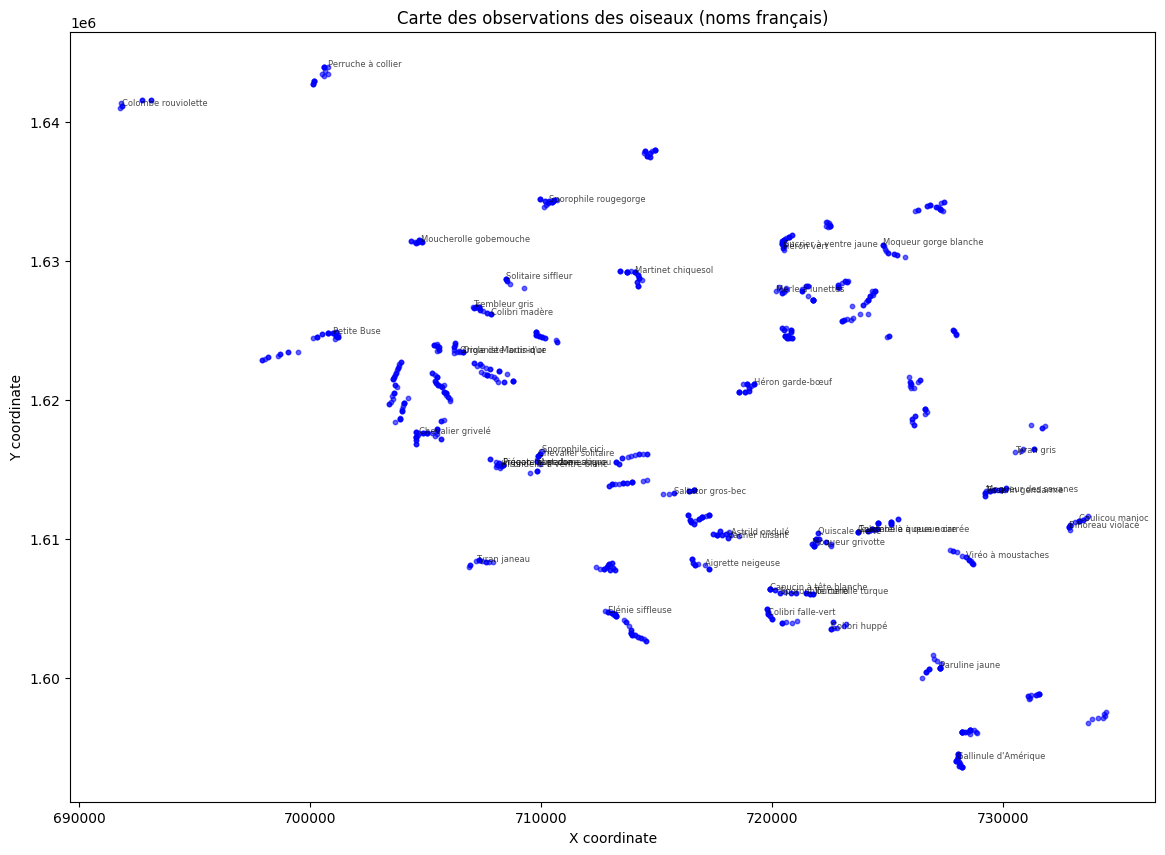

In [18]:
plt.figure(figsize=(14, 10))

df_map_sample = df_full.dropna(subset=['X', 'Y', 'french_name']).sample(1000, random_state=42)

plt.scatter(df_map_sample['X'], df_map_sample['Y'], s=10, alpha=0.6, color='blue')

for name, group in df_map_sample.groupby('french_name'):
    first = group.iloc[0]
    plt.text(first['X'], first['Y'], name, fontsize=6, alpha=0.7)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Carte des observations des oiseaux (noms français)")
plt.show()


C:\Users\AMINE\AppData\Local\Temp\ipykernel_18052\805912064.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(habitats))


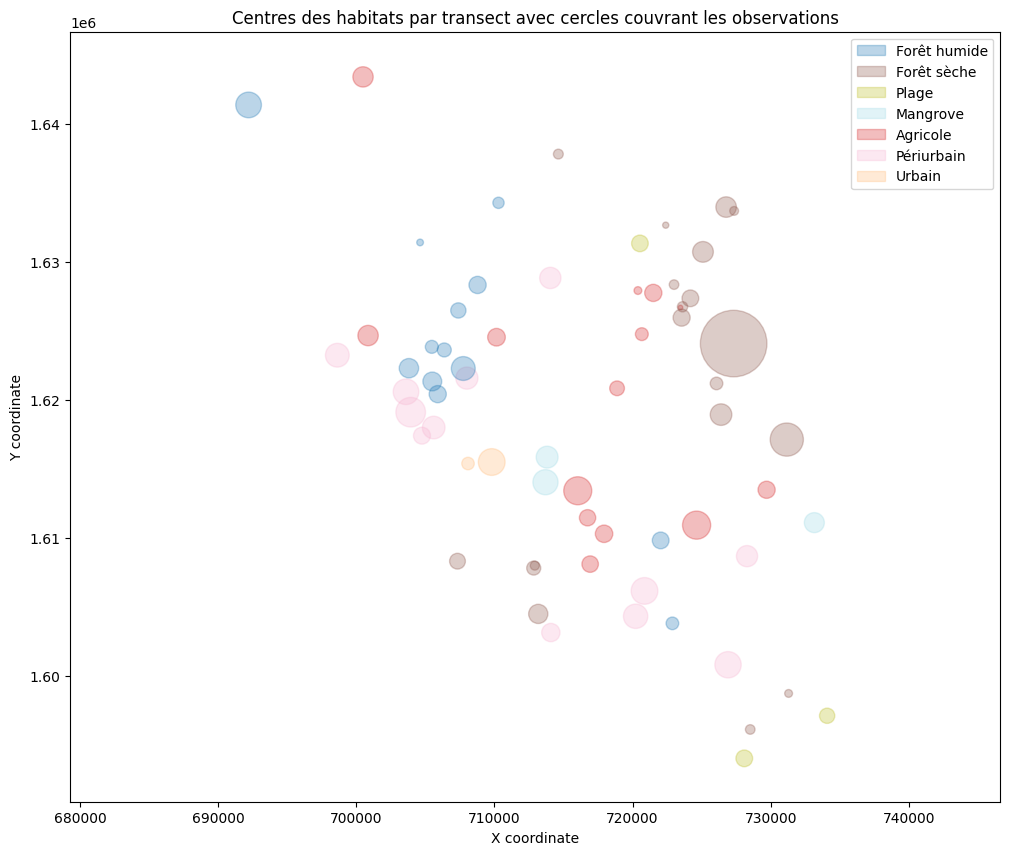

In [19]:
df_map = df_full.dropna(subset=['X', 'Y', 'habitat'])

habitats = df_map['habitat'].unique()
colors = plt.cm.get_cmap('tab20', len(habitats))
habitat_color = {hab: colors(i) for i, hab in enumerate(habitats)}

plt.figure(figsize=(12, 10))

df_map_grouped = df_map.groupby(['transect', 'habitat'])

for (transect, hab), df_h in df_map_grouped:
    center_x = df_h['X'].mean()
    center_y = df_h['Y'].mean()
    radius = max(np.sqrt((df_h['X'] - center_x)**2 + (df_h['Y'] - center_y)**2))
    
    circle = plt.Circle((center_x, center_y), radius, 
                        color=habitat_color[hab], alpha=0.3, label=hab)
    plt.gca().add_patch(circle)
    
    #plt.scatter(center_x, center_y, color=habitat_color[hab], edgecolor='k', s=50)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Centres des habitats par transect avec cercles couvrant les observations")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), markerscale=2)

plt.axis('equal')  
plt.show()


C:\Users\AMINE\AppData\Local\Temp\ipykernel_18052\1509554875.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(habitats))


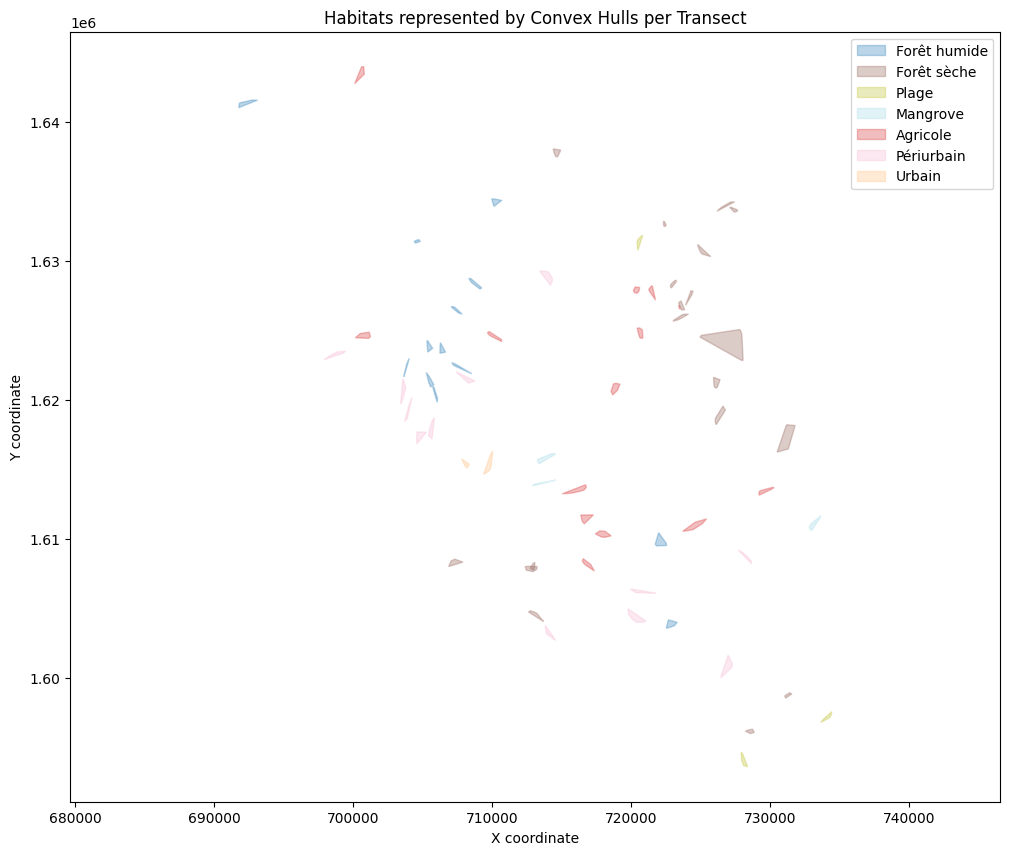

In [20]:
from scipy.spatial import ConvexHull

df_map = df_full.dropna(subset=['X', 'Y', 'habitat'])

habitats = df_map['habitat'].unique()
colors = plt.cm.get_cmap('tab20', len(habitats))
habitat_color = {hab: colors(i) for i, hab in enumerate(habitats)}

plt.figure(figsize=(12, 10))

df_map_grouped = df_map.groupby(['transect', 'habitat'])

for (transect, hab), df_h in df_map_grouped:
    points = df_h[['X', 'Y']].values
    
    if len(points) >= 3:
        hull = ConvexHull(points)
        plt.fill(points[hull.vertices,0], points[hull.vertices,1], 
                color=habitat_color[hab], alpha=0.3, label=hab)
    
    center_x = points[:,0].mean()
    center_y = points[:,1].mean()
    #plt.scatter(center_x, center_y, color=habitat_color[hab], edgecolor='k', s=50)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Habitats represented by Convex Hulls per Transect")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), markerscale=2)

plt.axis('equal')
plt.show()



C:\Users\AMINE\AppData\Local\Temp\ipykernel_18052\3243501194.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(habitats))
C:\Users\AMINE\AppData\Local\Temp\ipykernel_18052\3243501194.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  species_colors = plt.cm.get_cmap('tab20b', len(species))


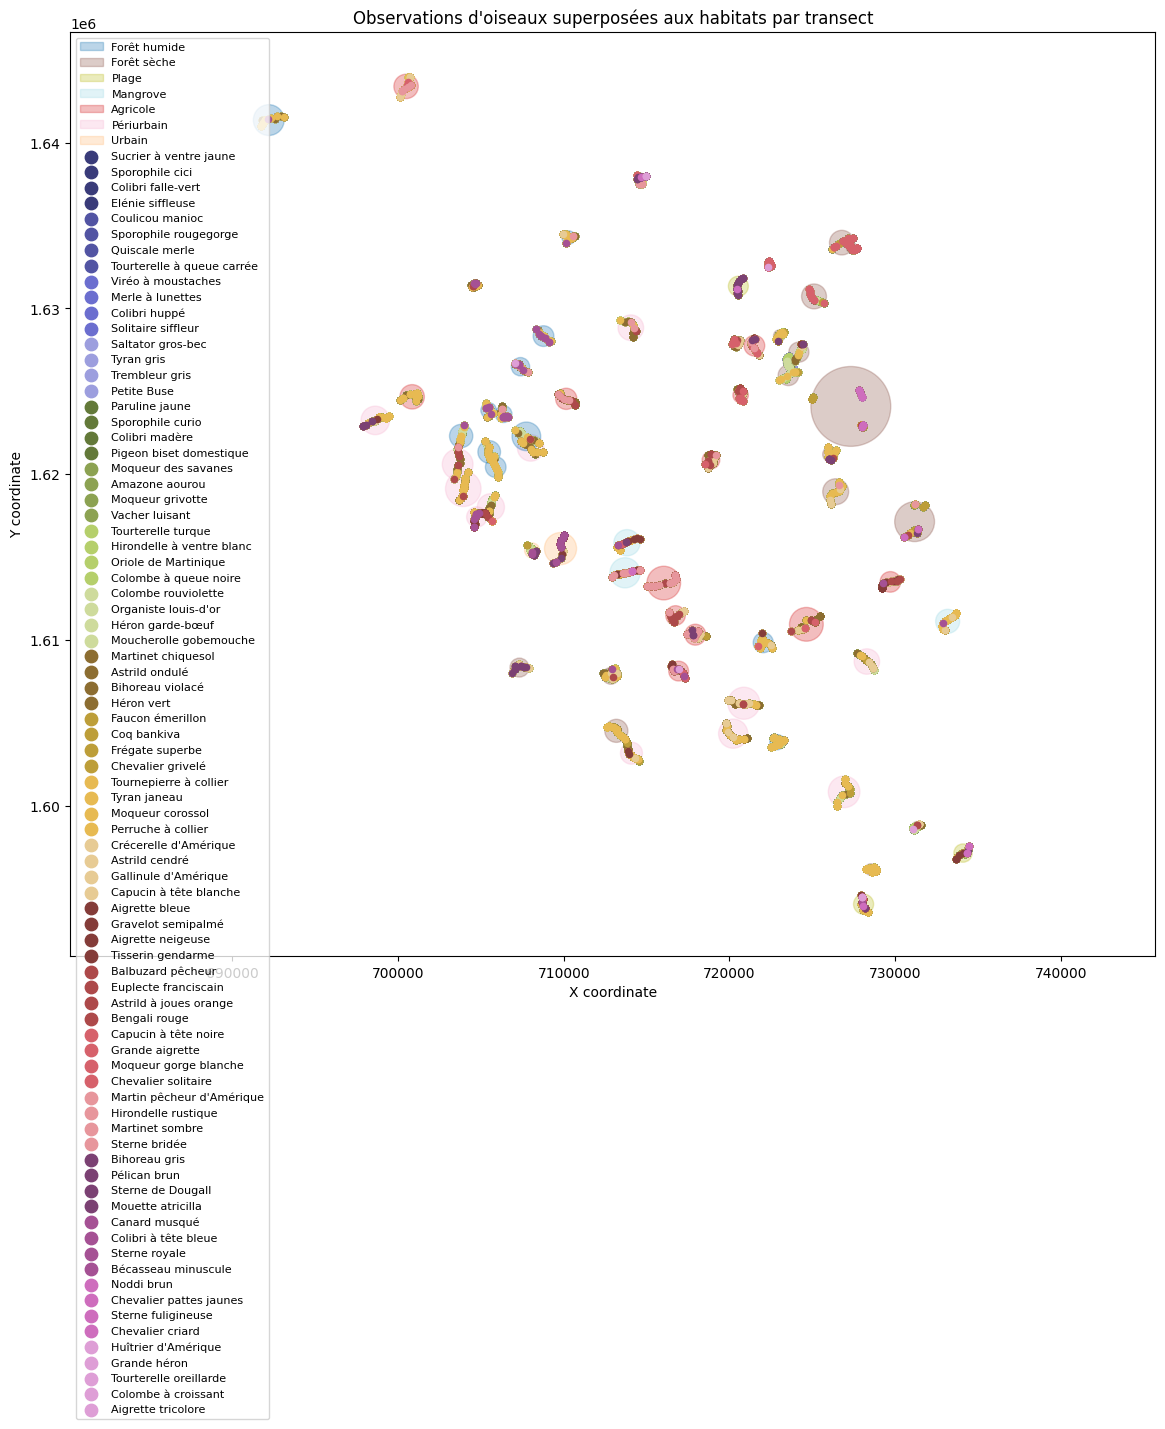

In [21]:
colors = plt.cm.get_cmap('tab20', len(habitats))
habitat_color = {hab: colors(i) for i, hab in enumerate(habitats)}

species = df_map['french_name'].unique()
species_colors = plt.cm.get_cmap('tab20b', len(species))
species_color = {sp: species_colors(i) for i, sp in enumerate(species)}

plt.figure(figsize=(14, 12))

df_map_grouped = df_map.groupby(['transect', 'habitat'])
for (transect, hab), df_h in df_map_grouped:
    center_x = df_h['X'].mean()
    center_y = df_h['Y'].mean()
    radius = max(np.sqrt((df_h['X'] - center_x)**2 + (df_h['Y'] - center_y)**2))
    
    circle = plt.Circle((center_x, center_y), radius, 
                        color=habitat_color[hab], alpha=0.3, label=hab)
    plt.gca().add_patch(circle)

for sp in species:
    df_sp = df_map[df_map['french_name'] == sp]
    plt.scatter(df_sp['X'], df_sp['Y'], 
                color=species_color[sp], s=20, label=sp)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Observations d'oiseaux superposées aux habitats par transect")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), markerscale=2, fontsize=8)

plt.axis('equal')
plt.show()


# Tentatives plus esthétiques (pas au point)

In [22]:
import plotly.express as px

df_map = df_full.dropna(subset=['X', 'Y', 'french_name', 'habitat']).sample(
    n=min(10000, len(df_full)), random_state=42
)

df_map['species_color'] = df_map['french_name']

fig = px.scatter(
    df_map,
    x='X',
    y='Y',
    color='species_color',       
    hover_name='french_name',    
    hover_data=['habitat'],      
    title='Sampled observations of birds with habitats',
    width=1200,
    height=800
)

for i, hab in enumerate(df_map['habitat'].unique()):
    df_h = df_map[df_map['habitat'] == hab]
    fig.add_shape(
        type='rect',
        x0=df_h['X'].min(),
        y0=df_h['Y'].min(),
        x1=df_h['X'].max(),
        y1=df_h['Y'].max(),
        fillcolor=px.colors.qualitative.Pastel[i % 10],
        opacity=0.2,
        line_width=0,
        layer='below'  
    )

fig.update_layout(
    xaxis_title='X coordinate',
    yaxis_title='Y coordinate',
    legend_title='Species',
)
fig.show()


In [23]:
df_obs_map = df_full.dropna(subset=['X','Y','french_name','habitat'])

habitat_colors = {
    'Forêt humide': 'forestgreen',
    'Urbain': 'lightgrey',
    'Agricole': 'sandybrown',
    'Forêt sèche': 'gold',
    'Périurbain': 'silver',
    'Plage': 'lightyellow',
    'Mangrove': 'green'
}

df_transects = df_gps.groupby('transect').agg(
    X_min=('X','min'), X_max=('X','max'),
    Y_min=('Y','min'), Y_max=('Y','max'),
    habitat=('habitat','first')
).sort_values('X_min').reset_index()

fig = px.scatter(
    df_obs_map,
    x='X', y='Y',
    color='french_name',
    hover_name='french_name',
    width=1200, height=800,
    title='Observations des oiseaux avec fond habitats entièrement rempli'
)

for i, row in df_transects.iterrows():
    color = habitat_colors[row['habitat']]
    fig.add_shape(
        type='rect',
        x0=row['X_min'],
        y0=row['Y_min'],
        x1=row['X_max'],
        y1=row['Y_max'],
        fillcolor=color,
        line_width=0,
        layer='below'
    )
    if i < len(df_transects)-1:
        next_row = df_transects.iloc[i+1]
        mid_x = (row['X_max'] + next_row['X_min']) / 2
        fig.add_shape(
            type='rect',
            x0=row['X_max'],
            y0=row['Y_min'],
            x1=mid_x,
            y1=row['Y_max'],
            fillcolor=color,
            line_width=0,
            layer='below'
        )
        next_color = habitat_colors[next_row['habitat']]
        fig.add_shape(
            type='rect',
            x0=mid_x,
            y0=row['Y_min'],
            x1=next_row['X_min'],
            y1=row['Y_max'],
            fillcolor=next_color,
            line_width=0,
            layer='below'
        )

fig.update_layout(
    xaxis_title='X',
    yaxis_title='Y',
    legend_title='Espèces'
)

fig.show()


In [24]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Sélection des top observateurs/transects
top_observers = df_full['observer'].value_counts().nlargest(10).index
top_transects = df_full['transect'].value_counts().nlargest(10).index

df_small = df_full[df_full['observer'].isin(top_observers) & 
            df_full['transect'].isin(top_transects)].copy()

# Créer total_detections et year
df_small['total_detections'] = df_small['auditory_total'].fillna(0) + df_small['visual__no_flight_total'].fillna(0)
df_small['year'] = df_small['date'].dt.year

# Fit GLM
model = smf.glm("total_detections ~ observer + transect + year",
                data=df_small,
                family=sm.families.Poisson()).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:       total_detections   No. Observations:                16904
Model:                            GLM   Df Residuals:                    16891
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -31509.
Date:                Wed, 05 Nov 2025   Deviance:                       20532.
Time:                        20:44:09   Pearson chi2:                 2.98e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01923
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [25]:
df_full.head()

,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes,french_name,scientific_name,status,X,Y,habitat
0,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1.0,1.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,706274,1624126,Forêt humide
1,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,1.0,1.0,1.0,NaN,Sporophile cici,Melanospiza bicolor ou Tiaris bicolor,Autochtone,706274,1624126,Forêt humide
2,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,2.0,2.0,2.0,NaN,Colibri falle-vert,Eulampis h. holosericeus,Endémique des Petites Antilles,706274,1624126,Forêt humide
3,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1.0,1.0,NaN,Elénie siffleuse,Elaenia m. martinica,Autochtone,706274,1624126,Forêt humide
4,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1.0,1.0,NaN,Coulicou manioc,Coccyzus minor,Autochtone,706274,1624126,Forêt humide


# Analyse Descriptive

In [26]:
import seaborn as sns

# Configuration graphiques
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Convertir date en datetime si nécessaire
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['year'] = df_full['date'].dt.year
df_full['month'] = df_full['date'].dt.month

# Vue d'ensemble
print("="*60)
print("STRUCTURE DU DATASET")
print("="*60)
print(f"Dimensions : {df_full.shape[0]:,} observations × {df_full.shape[1]} colonnes")
print(f"Période : {df_full['date'].min().date()} → {df_full['date'].max().date()}")
print(f"Années : {df_full['year'].min()} - {df_full['year'].max()} ({df_full['year'].nunique()} années)")
print(f"\nIdentifiants uniques :")
print(f"  - Transects : {df_full['transect'].nunique()}")
print(f"  - Points d'écoute : {df_full['point'].nunique()}")
print(f"  - Observateurs : {df_full['observer'].nunique()}")
print(f"  - Espèces : {df_full['scientific_name'].nunique()}")
print(f"  - Habitats : {df_full['habitat'].nunique()}")
print(f"  - Départements : {df_full['dept_code'].nunique()}")
print("\n")

# Liste des éléments
print("Transects :")
print(df_full['transect'].value_counts().head(10))
print("\nHabitats :")
print(df_full['habitat'].value_counts())
print("\nStatuts des espèces :")
print(df_full['status'].value_counts())

STRUCTURE DU DATASET
Dimensions : 114,088 observations × 34 colonnes
Période : 2014-03-29 → 2025-07-03
Années : 2014 - 2025 (12 années)

Identifiants uniques :
  - Transects : 65
  - Points d'écoute : 10
  - Observateurs : 49
  - Espèces : 81
  - Habitats : 7
  - Départements : 41


Transects :
transect
morne babet                  2902
habitation petite rivière    2839
moulin à vent                2825
là-haut                      2380
hôtel des plaisirs           2372
autre bord                   2336
borelie                      2283
fond rousseau                2232
jeannot                      2211
o'mullane                    2208
Name: count, dtype: int64

Habitats :
habitat
Forêt sèche     26960
Agricole        26817
Périurbain      24718
Forêt humide    20433
Plage            5750
Mangrove         5481
Urbain           3929
Name: count, dtype: int64

Statuts des espèces :
status
Autochtone                        77261
Endémique des Petites Antilles    19958
Exogène colonisateu

## Efforts (nb observations .. etc)

In [27]:
# ============= EFFORT ANNUEL =============
print("\n" + "="*60)
print("EFFORT D'OBSERVATION PAR ANNÉE")
print("="*60)

effort_annual = df_full.groupby('year').agg({
    'transect': 'nunique',
    'point': 'nunique',
    'visit_number': 'max',
    'observer': 'nunique',
    'date': 'count'
}).rename(columns={
    'transect': 'nb_transects',
    'point': 'nb_points',
    'visit_number': 'max_visits',
    'observer': 'nb_observers',
    'date': 'nb_observations'
})

print(effort_annual)


EFFORT D'OBSERVATION PAR ANNÉE
      nb_transects  nb_points  max_visits  nb_observers  nb_observations
year                                                                    
2014            41         10           2            24             5276
2015            53         10           2            27             7980
2016            59         10           2            29            10852
2017            60         10           2            27             9172
2018            64         10           2            24             9687
2019            64         10           2            23             9537
2020            63         10           2            15            10017
2021            63         10           2            13            10662
2022            63         10           2            15            10857
2023            64         10           2            15            10216
2024            64         10           2            24            10031
2025            65 

In [28]:
# Nombre de points-visites uniques par an
effort_annual['points_visits'] = df_full.groupby('year').apply(
    lambda x: x[['transect', 'point', 'visit_number']].drop_duplicates().shape[0]
).values

print("\nPoints-visites par année :")
print(effort_annual['points_visits'])


Points-visites par année :
year
2014     768
2015    1051
2016    1140
2017    1168
2018    1248
2019    1246
2020    1148
2021    1254
2022    1259
2023    1237
2024    1262
2025    1269
Name: points_visits, dtype: int64


In [29]:
# ============= EFFORT PAR TRANSECT =============
print("\n" + "="*60)
print("EFFORT PAR TRANSECT")
print("="*60)

effort_transect = df_full.groupby('transect').agg({
    'date': ['count', 'nunique'],
    'year': 'nunique',
    'point': 'nunique',
    'observer': 'nunique'
})
effort_transect.columns = ['nb_obs', 'nb_dates', 'nb_years', 'nb_points', 'nb_observers']
effort_transect = effort_transect.sort_values('nb_obs', ascending=False)
print(effort_transect)


EFFORT PAR TRANSECT
                              nb_obs  nb_dates  nb_years  nb_points  \
transect                                                              
morne babet                     2902        24        12         10   
habitation petite rivière       2839        26        12         10   
moulin à vent                   2825        24        12         10   
là-haut                         2380        23        12         10   
hôtel des plaisirs              2372        23        12         10   
...                              ...       ...       ...        ...   
ilets du françois               1112        16         9         10   
route forestière de palourde    1049        21        11         10   
galion 2                         887        18         9         10   
forêt vatable 2                  886        15         8         10   
bois pothau                      132         2         1         10   

                              nb_observers  
transect  

In [30]:
# ============= SAISONNALITÉ =============
effort_monthly = df_full.groupby(['year', 'month']).size().reset_index(name='nb_obs')

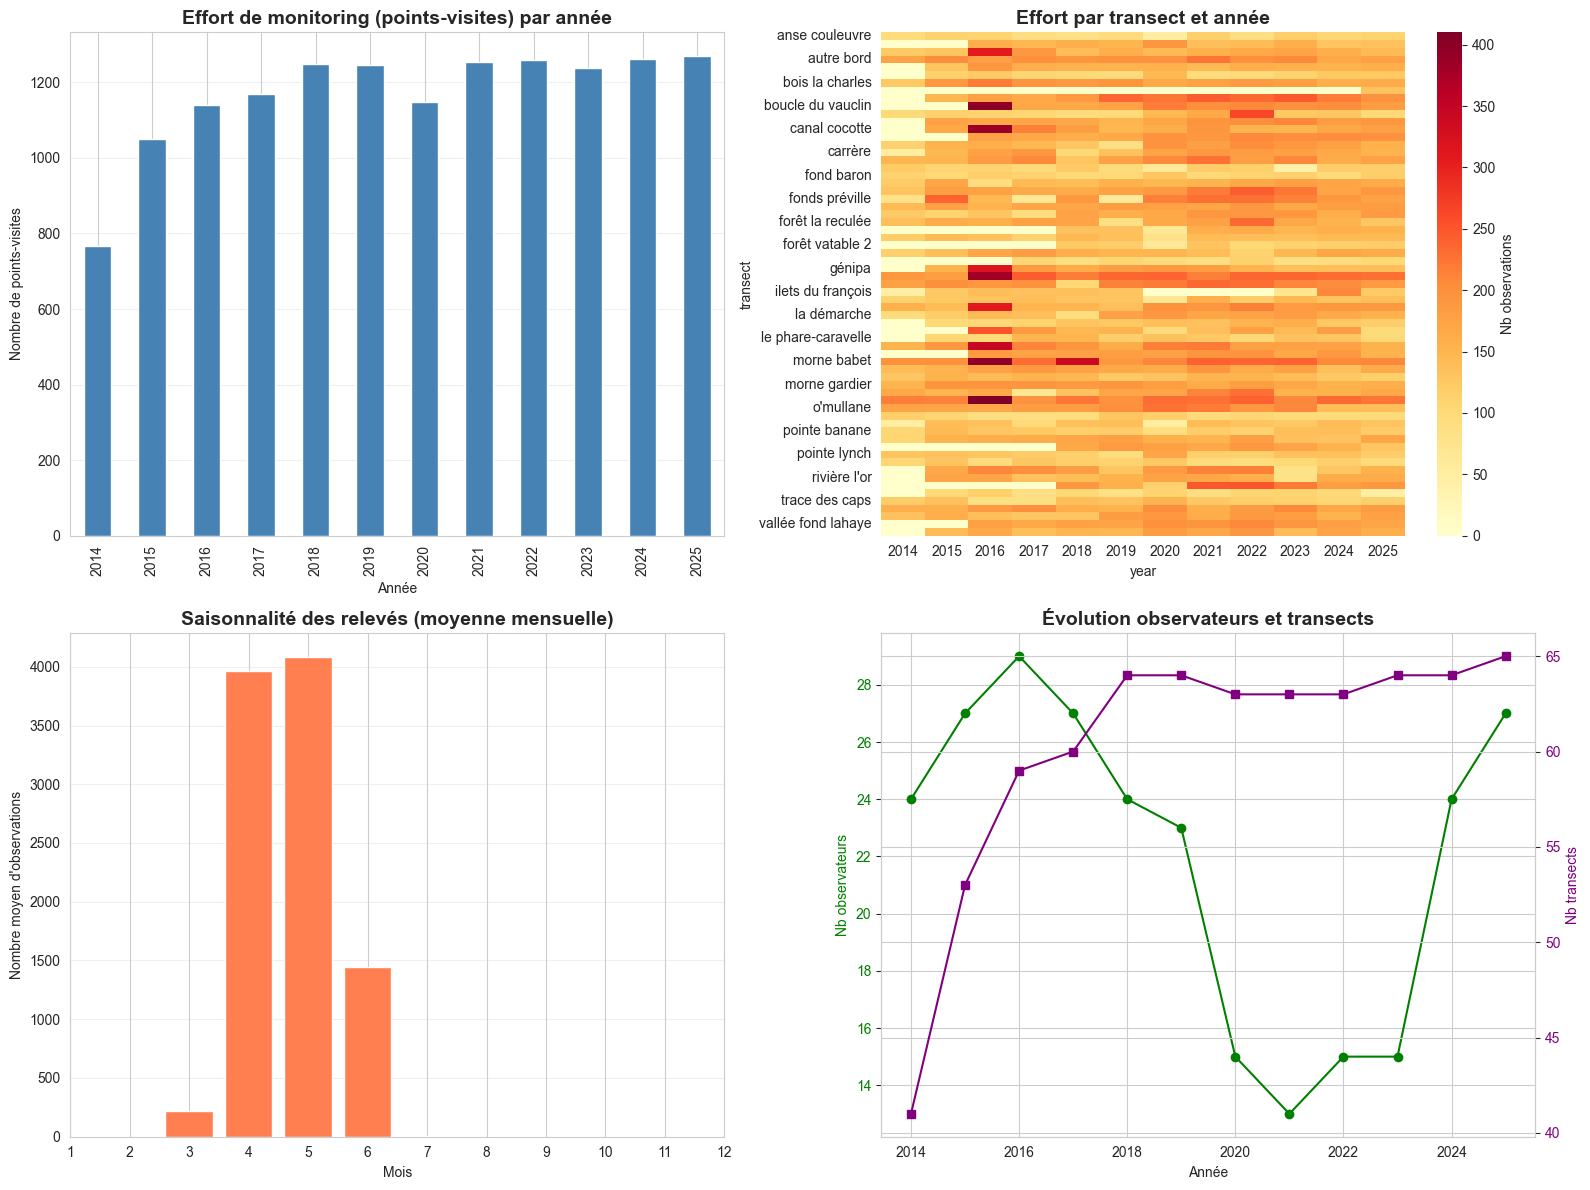

In [31]:
# ============= VISUALISATIONS EFFORT =============
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Évolution annuelle
effort_annual['points_visits'].plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Effort de monitoring (points-visites) par année', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Année')
axes[0,0].set_ylabel('Nombre de points-visites')
axes[0,0].grid(axis='y', alpha=0.3)

# Heatmap transects × années
pivot_transect = df_full.groupby(['transect', 'year']).size().reset_index(name='count')
pivot_transect = pivot_transect.pivot(index='transect', columns='year', values='count').fillna(0)
sns.heatmap(pivot_transect, cmap='YlOrRd', ax=axes[0,1], cbar_kws={'label': 'Nb observations'})
axes[0,1].set_title('Effort par transect et année', fontsize=14, fontweight='bold')

# Saisonnalité
monthly_avg = effort_monthly.groupby('month')['nb_obs'].mean()
axes[1,0].bar(monthly_avg.index, monthly_avg.values, color='coral')
axes[1,0].set_title('Saisonnalité des relevés (moyenne mensuelle)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Mois')
axes[1,0].set_ylabel('Nombre moyen d\'observations')
axes[1,0].set_xticks(range(1, 13))
axes[1,0].grid(axis='y', alpha=0.3)

# Évolution nb observateurs et transects
ax_twin = axes[1,1]
effort_annual['nb_observers'].plot(ax=ax_twin, marker='o', label='Observateurs', color='green')
ax_twin.set_ylabel('Nb observateurs', color='green')
ax_twin.tick_params(axis='y', labelcolor='green')

ax_twin2 = ax_twin.twinx()
effort_annual['nb_transects'].plot(ax=ax_twin2, marker='s', label='Transects', color='purple')
ax_twin2.set_ylabel('Nb transects', color='purple')
ax_twin2.tick_params(axis='y', labelcolor='purple')

axes[1,1].set_title('Évolution observateurs et transects', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Année')

plt.tight_layout()
#plt.savefig('effort_monitoring.png', dpi=300, bbox_inches='tight')
plt.show()

## Météo

In [32]:
print("\n" + "="*60)
print("CONDITIONS MÉTÉOROLOGIQUES")
print("="*60)

weather_vars = ['clouds', 'rain', 'wind', 'visibility']
weather_stats = df_full[weather_vars].describe()
print(weather_stats)


CONDITIONS MÉTÉOROLOGIQUES
              clouds           rain           wind     visibility
count  114088.000000  114088.000000  114088.000000  114088.000000
mean        1.968671       1.028925       1.424143       1.417090
std         0.698015       0.176363       0.601033       0.618845
min         0.000000       0.000000      -5.000000       0.000000
25%         1.000000       1.000000       1.000000       1.000000
50%         2.000000       1.000000       1.000000       1.000000
75%         2.000000       1.000000       2.000000       2.000000
max         3.000000       3.000000       3.000000       4.000000


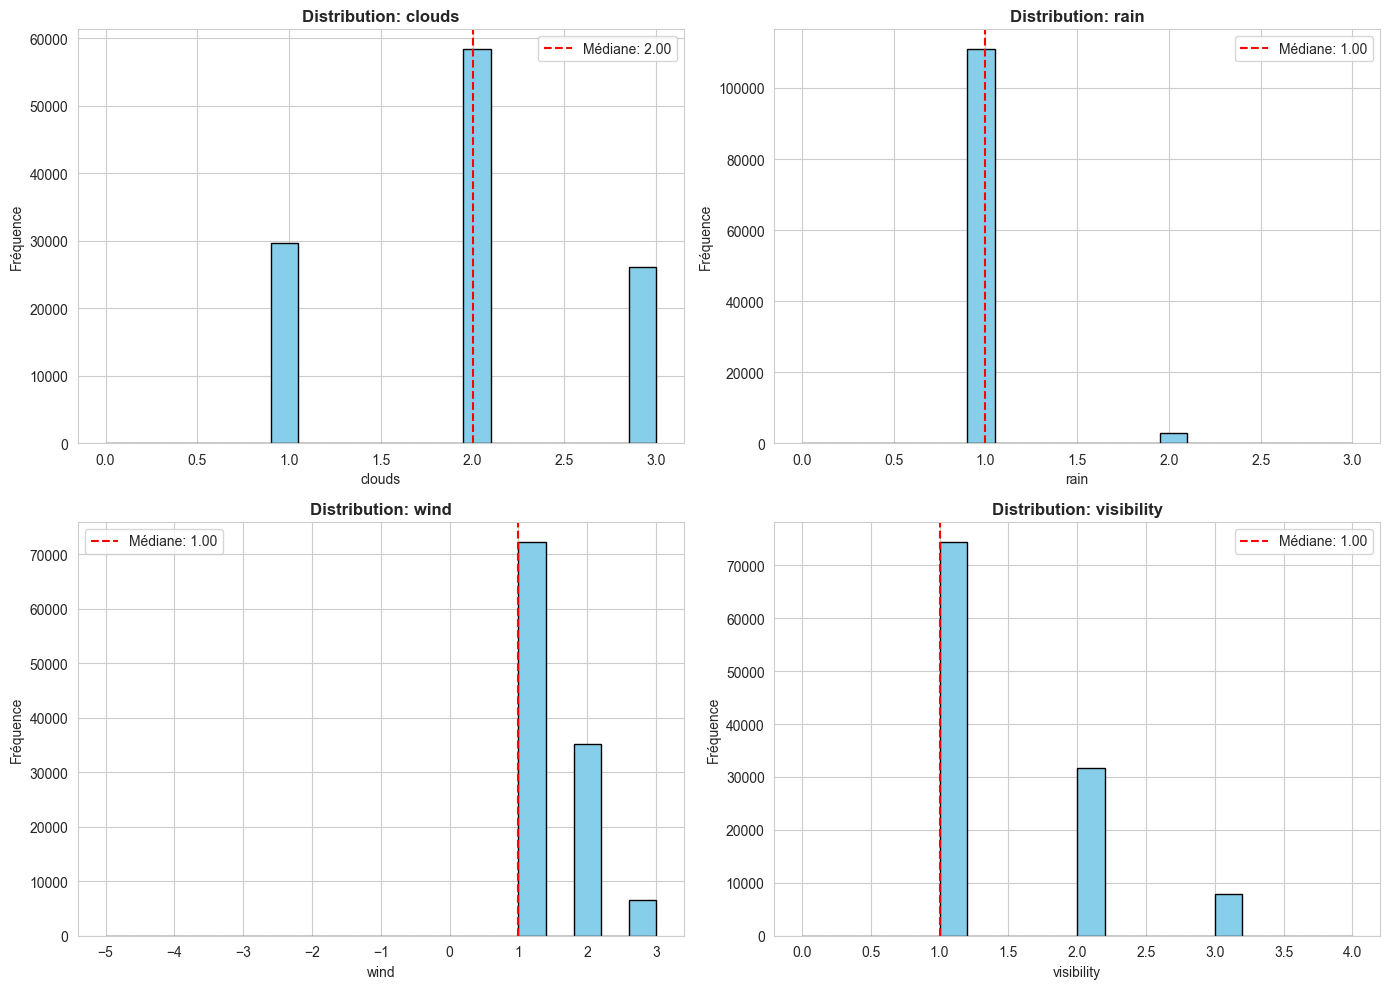

In [33]:
# ============= VISUALISATIONS MÉTÉO =============
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, var in enumerate(weather_vars):
    ax = axes[idx//2, idx%2]
    df_full[var].hist(bins=20, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribution: {var}', fontsize=12, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Fréquence')
    ax.axvline(df_full[var].median(), color='red', linestyle='--', label=f'Médiane: {df_full[var].median():.2f}')
    ax.legend()

plt.tight_layout()
#plt.savefig('conditions_meteo.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\AMINE\AppData\Local\Temp\ipykernel_18052\2994635276.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




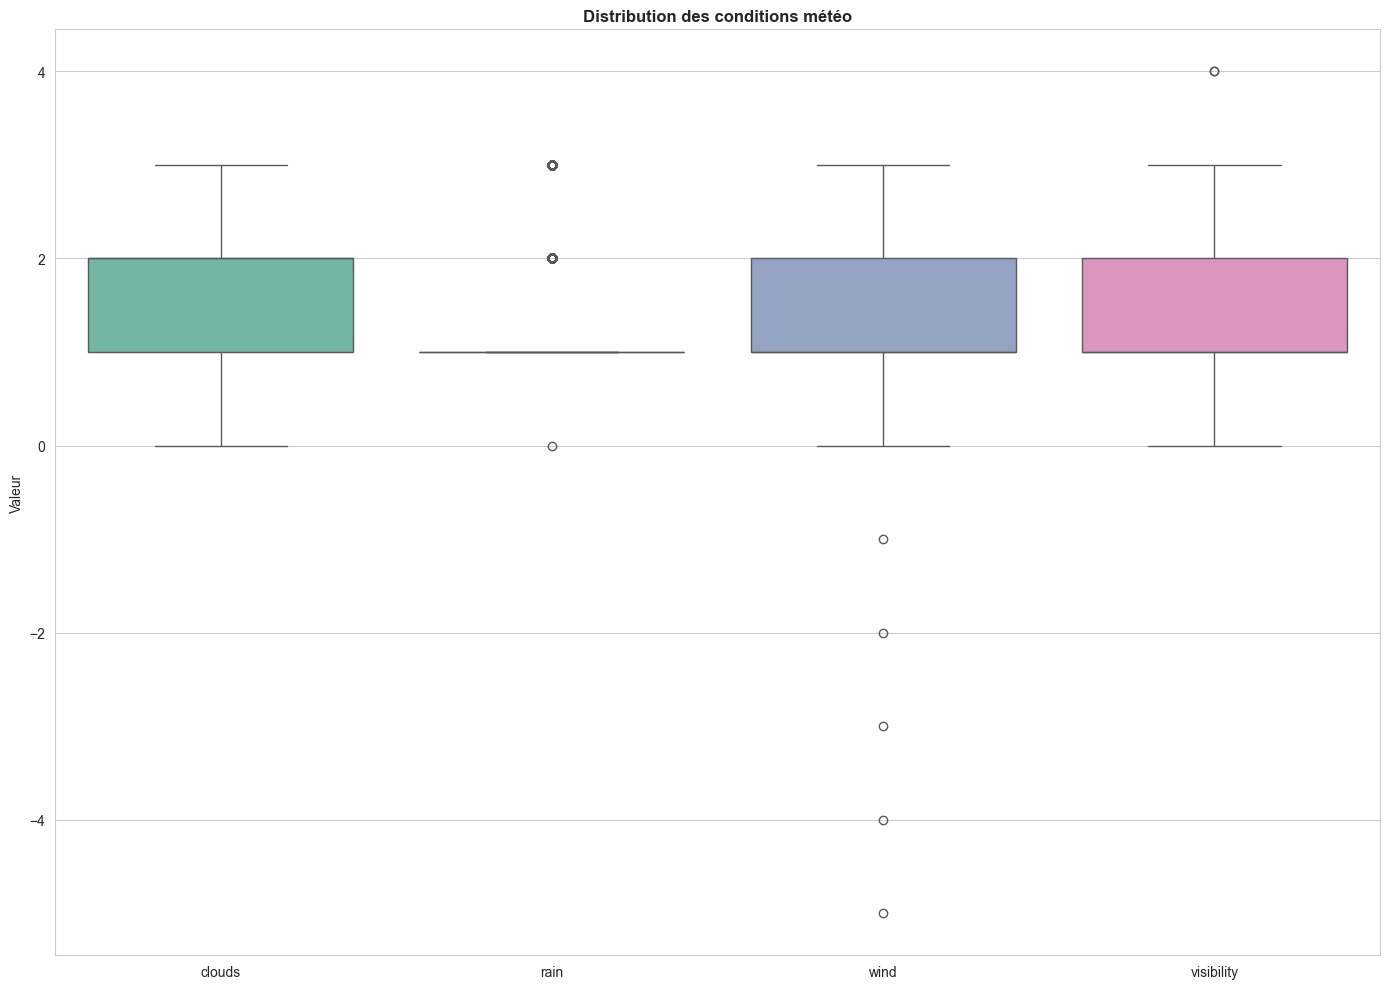

In [34]:
#Boxplots météo
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
weather_melted = df_full[weather_vars].melt(var_name='Variable', value_name='Valeur')
sns.boxplot(data=weather_melted, x='Variable', y='Valeur', ax=ax, palette='Set2')
ax.set_title('Distribution des conditions météo', fontsize=12, fontweight='bold')
ax.set_xlabel('')

plt.tight_layout()
#plt.savefig('partie1_effort_meteo.png', dpi=300, bbox_inches='tight')
plt.show()

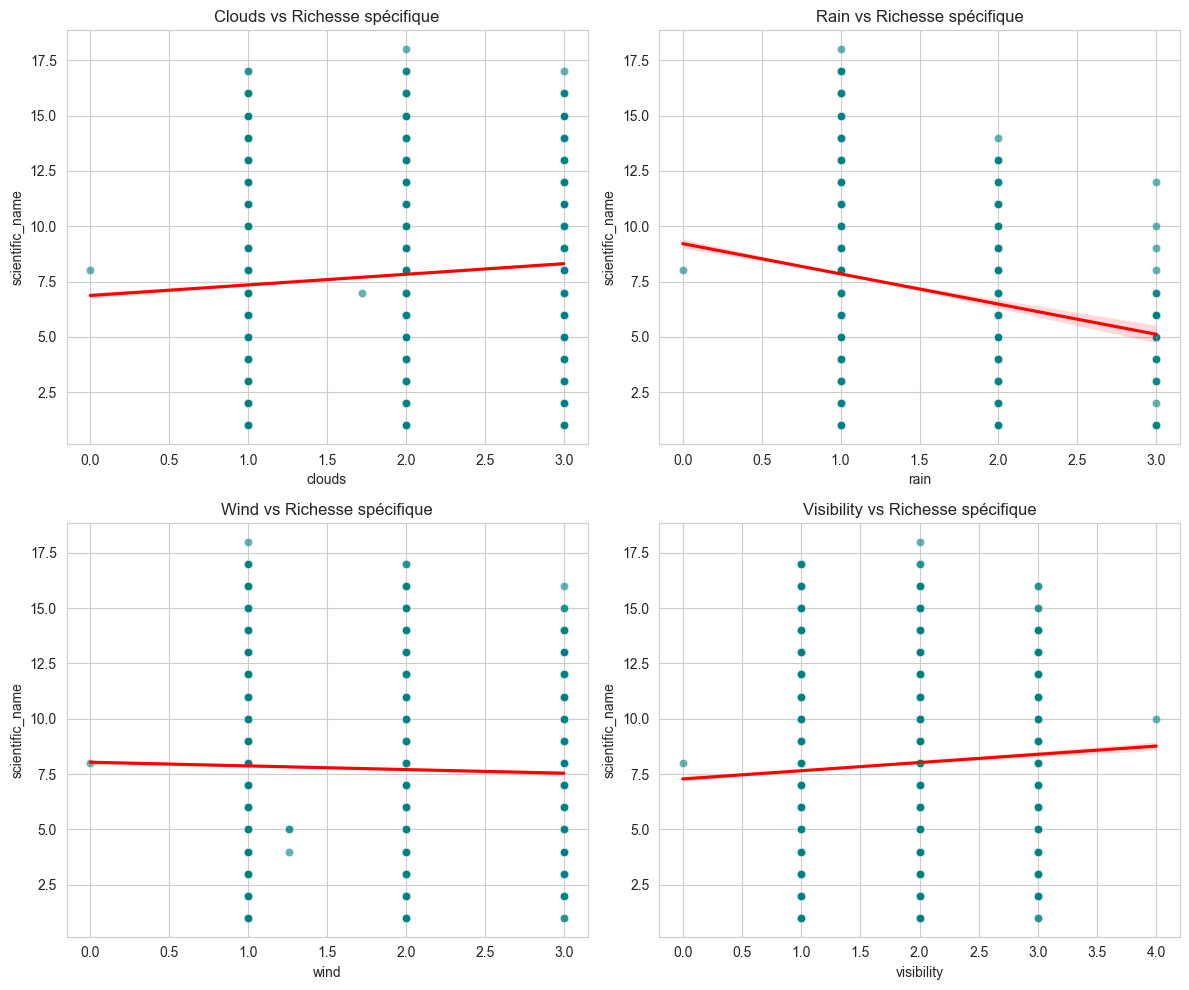

In [35]:
species_per_visit = df_full.groupby(['transect', 'point', 'visit_number', 'date']).agg(
                    { 'scientific_name': 'nunique', 'clouds': 'first', 'rain': 'first', 'wind': 'first', 'visibility': 'first' }
                    ).reset_index()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, var in enumerate(weather_vars):
    ax = axes[idx//2, idx%2]
    sns.scatterplot(data=species_per_visit, x=var, y='scientific_name', ax=ax, color='teal', alpha=0.6)
    sns.regplot(data=species_per_visit, x=var, y='scientific_name', ax=ax, scatter=False, color='red')
    ax.set_title(f"{var.capitalize()} vs Richesse spécifique")

plt.tight_layout()
#plt.savefig('impact_meteo_scatterplots.png', dpi=300, bbox_inches='tight')
plt.show()



COMPTAGES D'OISEAUX

Statistiques auditory_visual_with_flight_total :
count    114088.000000
mean          2.225379
std           2.883633
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max         200.000000
Name: auditory_visual_with_flight_total, dtype: float64

TOP 15 ESPÈCES LES PLUS ABONDANTES
french_name
Quiscale merle                38434.0
Sucrier à ventre jaune        30138.0
Elénie siffleuse              20655.0
Tourterelle à queue carrée    20387.0
Sporophile rougegorge         20103.0
Sporophile cici               14618.0
Tyran gris                    13523.0
Saltator gros-bec             10551.0
Viréo à moustaches             9372.0
Merle à lunettes               9252.0
Astrild ondulé                 8220.0
Héron garde-bœuf               5804.0
Vacher luisant                 4860.0
Pigeon biset domestique        4615.0
Moqueur des savanes            4458.0
Name: auditory_visual_with_flight_total, dtype: float64

MÉTHODES DE DÉ

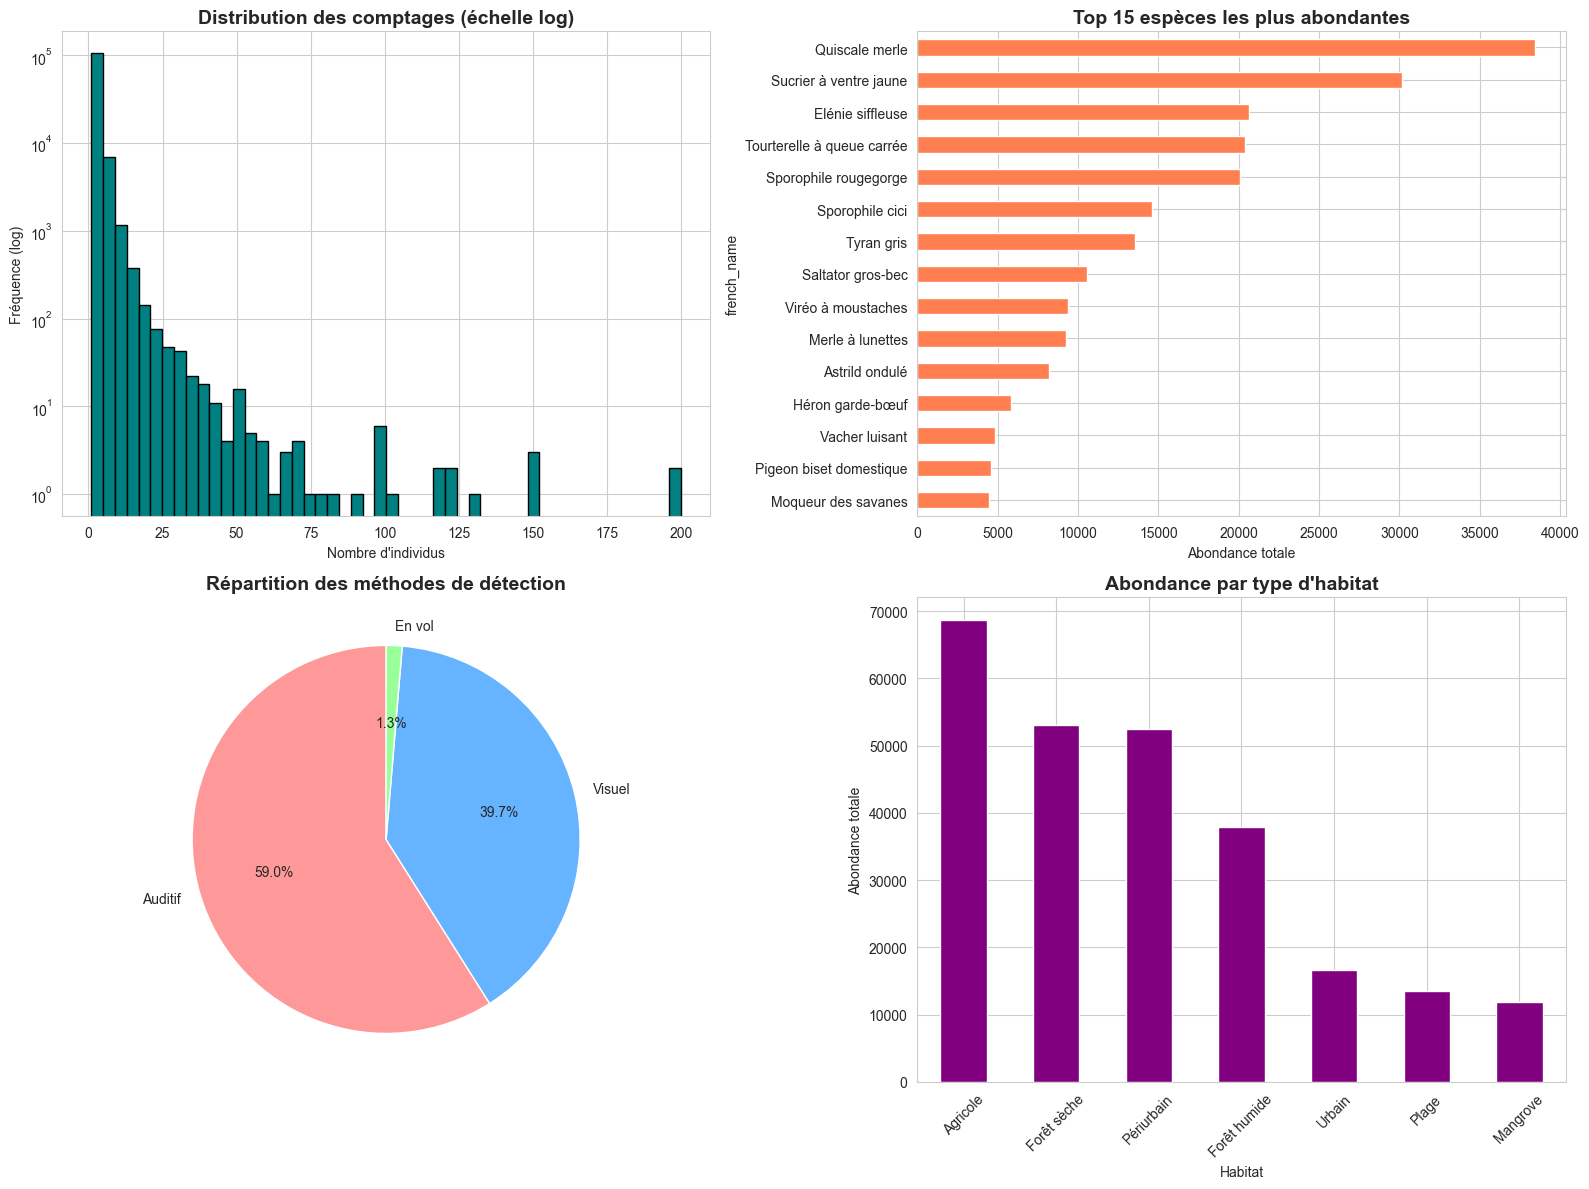

In [36]:
# ============= STATISTIQUES COMPTAGES =============
print("\n" + "="*60)
print("COMPTAGES D'OISEAUX")
print("="*60)

count_var = 'auditory_visual_with_flight_total'
print(f"\nStatistiques {count_var} :")
print(df_full[count_var].describe())

# Top espèces
print("\n" + "="*60)
print("TOP 15 ESPÈCES LES PLUS ABONDANTES")
print("="*60)

top_species = df_full.groupby('french_name')[count_var].sum().sort_values(ascending=False).head(15)
print(top_species)

# Méthodes de détection
total_auditory = df_full['auditory_total'].sum()
total_visual = df_full['visual__no_flight_total'].sum()
total_flight = (df_full['auditory_visual_with_flight_total'] - df_full['auditory_visual_no_flight_total']).sum()

print(f"\n" + "="*60)
print("MÉTHODES DE DÉTECTION")
print("="*60)
print(f"Total auditif : {total_auditory:,} ({total_auditory/(total_auditory+total_visual+total_flight)*100:.1f}%)")
print(f"Total visuel (sans vol) : {total_visual:,} ({total_visual/(total_auditory+total_visual+total_flight)*100:.1f}%)")
print(f"Total en vol : {total_flight:,} ({total_flight/(total_auditory+total_visual+total_flight)*100:.1f}%)")

# ============= VISUALISATIONS COMPTAGES =============
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution comptages (log scale)
axes[0,0].hist(df_full[count_var][df_full[count_var] > 0], bins=50, color='teal', edgecolor='black')
axes[0,0].set_yscale('log')
axes[0,0].set_title('Distribution des comptages (échelle log)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Nombre d\'individus')
axes[0,0].set_ylabel('Fréquence (log)')

# 2. Top espèces
top_species.plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Top 15 espèces les plus abondantes', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Abondance totale')
axes[0,1].invert_yaxis()

# 3. Méthodes de détection (pie chart)
detection_data = [total_auditory, total_visual, total_flight]
detection_labels = ['Auditif', 'Visuel', 'En vol']
axes[1,0].pie(detection_data, labels=detection_labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
axes[1,0].set_title('Répartition des méthodes de détection', fontsize=14, fontweight='bold')

# 4. Abondance par habitat
habitat_abundance = df_full.groupby('habitat')[count_var].sum().sort_values(ascending=False)
habitat_abundance.plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Abondance par type d\'habitat', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Habitat')
axes[1,1].set_ylabel('Abondance totale')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig('comptages_oiseaux.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
df_full.columns

Index(['observer', 'dept_code', 'transect', 'date', 'visit_number', 'clouds',
       'rain', 'wind', 'visibility', 'point', 'start_time', 'species',
       'auditory_0_25m', 'visual_0_25m', 'auditory_25_50m', 'visual_25_50m',
       'auditory_50_100m', 'visual_50_100m', 'auditory_100m_plus',
       'visual_100m_plus', 'flight', 'auditory_total',
       'visual__no_flight_total', 'auditory_visual_no_flight_total',
       'auditory_visual_with_flight_total', 'Notes', 'french_name',
       'scientific_name', 'status', 'X', 'Y', 'habitat', 'year', 'month'],
      dtype='object')


DÉTECTABILITÉ PAR DISTANCE
  Distance     Count  Percentage
0    0-25m  176404.0       70.41
1   25-50m   51595.0       20.59
2  50-100m   13315.0        5.31
3    100m+    9210.0        3.68


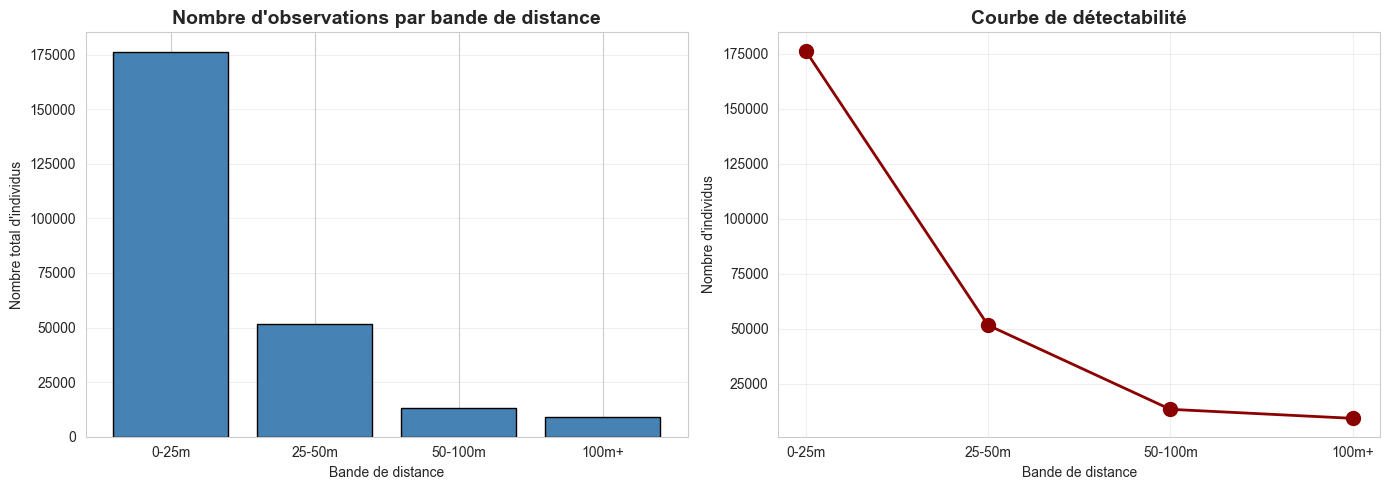

In [38]:
# ============= DÉTECTABILITÉ PAR DISTANCE =============
print("\n" + "="*60)
print("DÉTECTABILITÉ PAR DISTANCE")
print("="*60)

# Par bande de distance
distance_bands = {
    '0-25m': df_full['auditory_0_25m'].sum() + df_full['visual_0_25m'].sum(),
    '25-50m': df_full['auditory_25_50m'].sum() + df_full['visual_25_50m'].sum(),
    '50-100m': df_full['auditory_50_100m'].sum() + df_full['visual_50_100m'].sum(),
    '100m+': df_full['auditory_100m_plus'].sum() + df_full['visual_100m_plus'].sum()
}

distance_df = pd.DataFrame(list(distance_bands.items()), columns=['Distance', 'Count'])
distance_df['Percentage'] = (distance_df['Count'] / distance_df['Count'].sum() * 100).round(2)
print(distance_df)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(distance_df['Distance'], distance_df['Count'], color='steelblue', edgecolor='black')
axes[0].set_title('Nombre d\'observations par bande de distance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Bande de distance')
axes[0].set_ylabel('Nombre total d\'individus')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(range(len(distance_df)), distance_df['Count'], marker='o', linewidth=2, markersize=10, color='darkred')
axes[1].set_title('Courbe de détectabilité', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Bande de distance')
axes[1].set_ylabel('Nombre d\'individus')
axes[1].set_xticks(range(len(distance_df)))
axes[1].set_xticklabels(distance_df['Distance'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('detectabilite_distance.png', dpi=300, bbox_inches='tight')
plt.show()

# Indicateurs

In [39]:
# Sélectionner les colonnes pertinentes
cols_bio = ['transect', 'point', 'year', 'species']
df_bio = df_full[cols_bio].copy()

# Ajouter le comptage et filtrer les observations valides
df_bio['count'] = df_full['auditory_visual_with_flight_total'].fillna(0)
df_bio = df_bio[df_bio['count'] > 0]

# Compter le nombre d'espèces UNIQUES par transect et par année
richesse = (
    df_bio.groupby(['transect', 'year'])['species']
    .nunique()
    .reset_index()
    .rename(columns={'species': 'nb_especes'})
)

print(richesse)

           transect  year  nb_especes
0    anse couleuvre  2014          19
1    anse couleuvre  2015          18
2    anse couleuvre  2016          23
3    anse couleuvre  2017          17
4    anse couleuvre  2018          16
..              ...   ...         ...
718         verrier  2021          20
719         verrier  2022          24
720         verrier  2023          18
721         verrier  2024          24
722         verrier  2025          21

[723 rows x 3 columns]


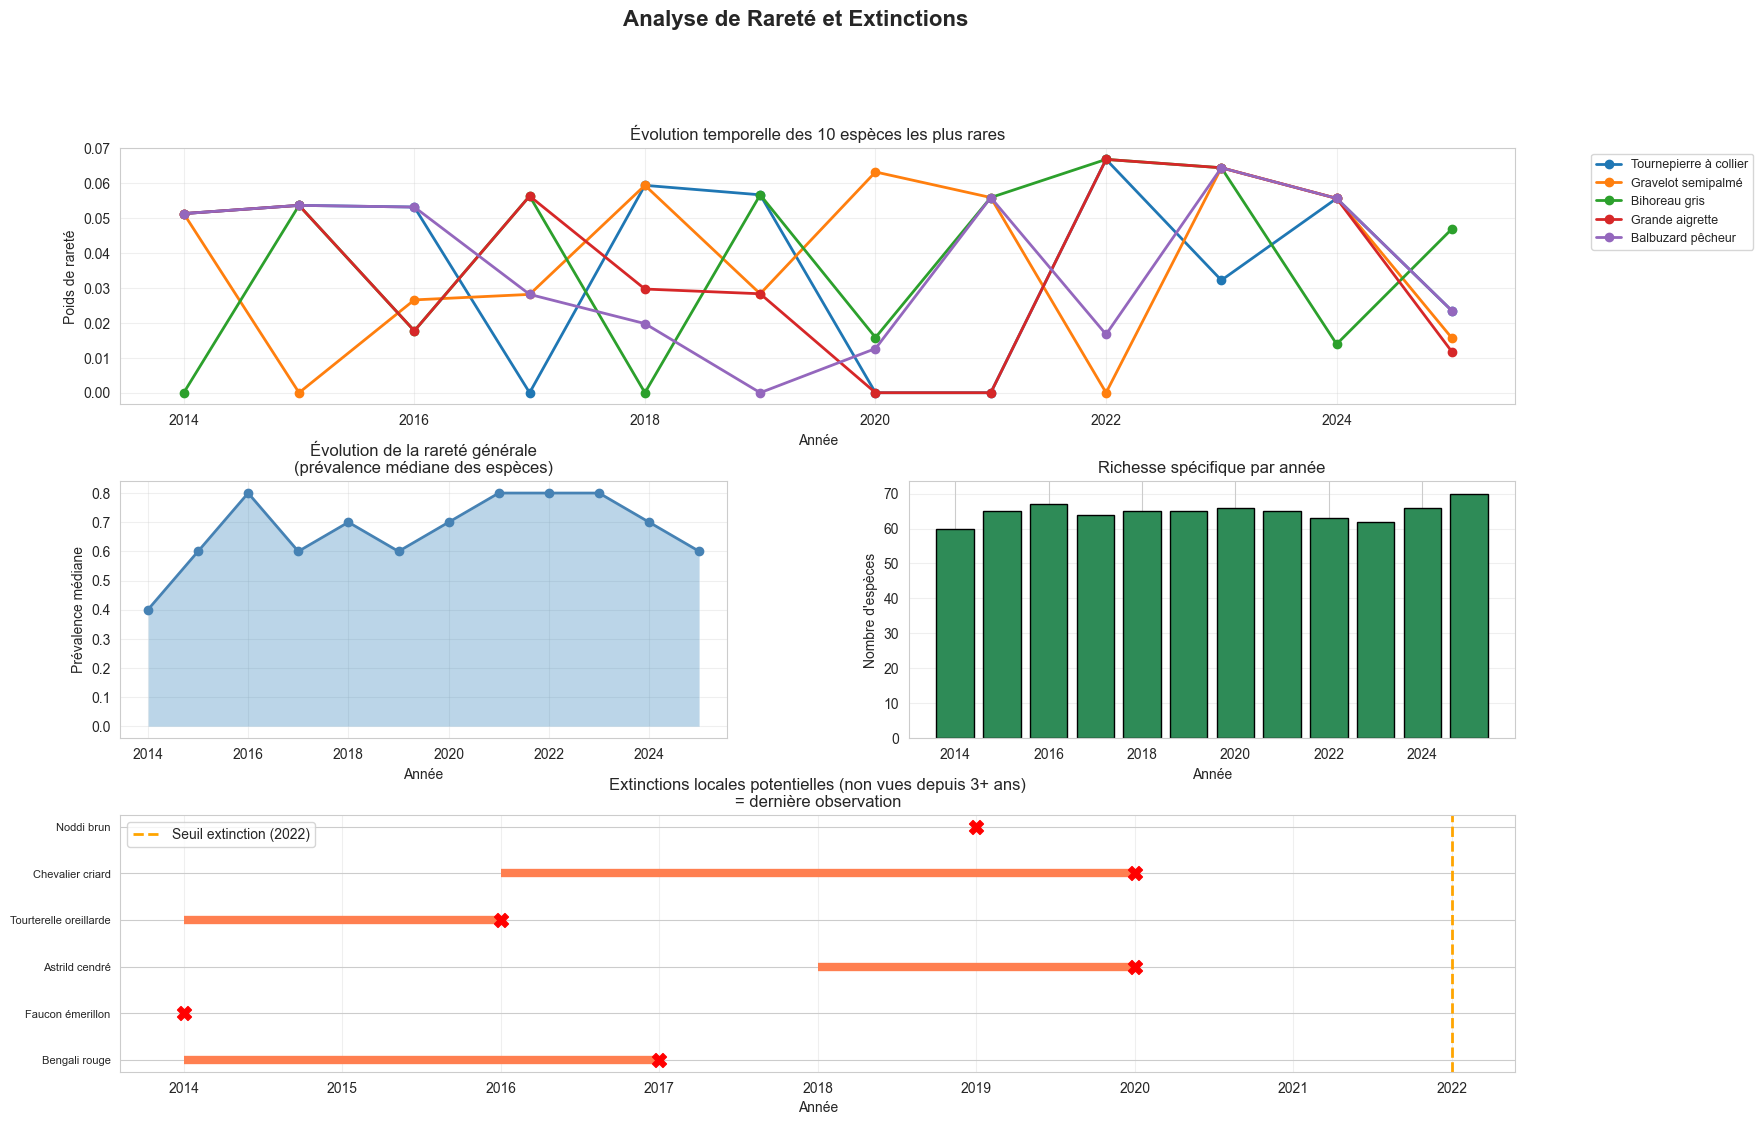


STATISTIQUES DE RARETÉ
Nombre total d'espèces observées : 81
Période : 2014 → 2025

Prévalence médiane par année :
year
2014    0.4
2015    0.6
2016    0.8
2017    0.6
2018    0.7
2019    0.6
2020    0.7
2021    0.8
2022    0.8
2023    0.8
2024    0.7
2025    0.6
Name: prevalence, dtype: float64

EXTINCTIONS POTENTIELLES
Nombre d'espèces non vues depuis 3+ ans : 6

Top 10 disparitions les plus anciennes :
               species  first_year  last_year  years_absent
         Bengali rouge        2014       2014            11
      Faucon émerillon        2014       2016             9
        Astrild cendré        2014       2017             8
Tourterelle oreillarde        2019       2019             6
      Chevalier criard        2018       2020             5
            Noddi brun        2016       2020             5


In [40]:
# === 1. RARETÉ PAR ANNÉE (avec espèces absentes = prévalence 0) ===
rarete_annuelle = []

all_species = df_bio['species'].unique()

for year in df_bio['year'].unique():
    df_year = df_bio[df_bio['year'] == year]
    
    n_points_year = df_year['point'].nunique()
    
    prev_year = df_year.groupby('species')['point'].nunique() / n_points_year
    
    for species in all_species:
        if species in prev_year.index:
            prevalence = prev_year[species]
        else:
            prevalence = 0.0  # Espèce absente cette année
        
        rarete_annuelle.append({
            'year': year,
            'species': species,
            'prevalence': prevalence
        })

df_rarete = pd.DataFrame(rarete_annuelle)

# Calculer les poids APRÈS (en excluant les prévalences = 0 pour éviter division par zéro)
df_rarete_actives = df_rarete[df_rarete['prevalence'] > 0].copy()

k = 1.0
for year in df_rarete_actives['year'].unique():
    mask = df_rarete_actives['year'] == year
    weights = 1 / (df_rarete_actives.loc[mask, 'prevalence'] ** k + 1e-6)
    df_rarete_actives.loc[mask, 'weight'] = weights / weights.sum()

# Ajouter weight = 0 pour les espèces absentes
df_rarete = df_rarete.merge(
    df_rarete_actives[['year', 'species', 'weight']], 
    on=['year', 'species'], 
    how='left'
)
df_rarete['weight'] = df_rarete['weight'].fillna(0)

# === 2. DÉTECTION DES EXTINCTIONS ===
# Première et dernière année d'observation par espèce
first_seen = df_bio.groupby('species')['year'].min()
last_seen = df_bio.groupby('species')['year'].max()
max_year = df_bio['year'].max()

# Espèces potentiellement éteintes (pas vues depuis 3+ ans)
seuil_extinction = 3
extinctions = last_seen[last_seen < (max_year - seuil_extinction)]

df_extinctions = pd.DataFrame({
    'species': extinctions.index,
    'first_year': first_seen[extinctions.index].values,
    'last_year': extinctions.values,
    'years_absent': max_year - extinctions.values
}).sort_values('last_year')

# === GRAPHIQUES ===
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)


# Top 10 espèces les plus rares par année
ax1 = fig.add_subplot(gs[0, :])

top_species = df_rarete.groupby('species')['weight'].mean().nlargest(5).index

for species in top_species:
    data = df_rarete[df_rarete['species'] == species].sort_values('year')
    ax1.plot(data['year'], data['weight'], marker='o', label=species[:25], linewidth=2)

ax1.set_xlabel('Année')
ax1.set_ylabel('Poids de rareté')
ax1.set_title('Évolution temporelle des 10 espèces les plus rares')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax1.grid(alpha=0.3)

# Évolution de la prévalence médiane
ax2 = fig.add_subplot(gs[1, 0])
prev_median = df_rarete.groupby('year')['prevalence'].median()
ax2.plot(prev_median.index, prev_median.values, marker='o', linewidth=2, color='steelblue')
ax2.fill_between(prev_median.index, prev_median.values, alpha=0.3)
ax2.set_xlabel('Année')
ax2.set_ylabel('Prévalence médiane')
ax2.set_title('Évolution de la rareté générale\n(prévalence médiane des espèces)')
ax2.grid(alpha=0.3)

# Nombre d'espèces observées par année
ax3 = fig.add_subplot(gs[1, 1])
n_species = df_bio.groupby('year')['species'].nunique()
ax3.bar(n_species.index, n_species.values, color='seagreen', edgecolor='black')
ax3.set_xlabel('Année')
ax3.set_ylabel('Nombre d\'espèces')
ax3.set_title('Richesse spécifique par année')
ax3.grid(axis='y', alpha=0.3)

# Timeline des extinctions
ax4 = fig.add_subplot(gs[2, :])
if len(df_extinctions) > 0:
    top_extinctions = df_extinctions.nlargest(20, 'years_absent')
    for idx, row in top_extinctions.iterrows():
        ax4.plot([row['first_year'], row['last_year']], [idx, idx], 
                linewidth=6, solid_capstyle='butt', color='coral')
        ax4.scatter(row['last_year'], idx, color='red', s=100, zorder=3, marker='X')
    ax4.set_yticks(range(len(top_extinctions)))
    ax4.set_yticklabels([sp[:30] for sp in top_extinctions['species']], fontsize=8)
    ax4.set_xlabel('Année')
    ax4.set_title(f'Extinctions locales potentielles (non vues depuis {seuil_extinction}+ ans)\n= dernière observation')
    ax4.axvline(max_year - seuil_extinction, color='orange', linestyle='--', 
                label=f'Seuil extinction ({max_year - seuil_extinction})', linewidth=2)
    ax4.legend()
    ax4.grid(axis='x', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Aucune extinction détectée', ha='center', va='center', fontsize=14)
    ax4.set_title('Extinctions locales')

plt.suptitle('Analyse de Rareté et Extinctions', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# === STATISTIQUES ===
print(f"\nSTATISTIQUES DE RARETÉ")
print(f"{'='*50}")
print(f"Nombre total d'espèces observées : {df_bio['species'].nunique()}")
print(f"Période : {df_bio['year'].min()} → {df_bio['year'].max()}")
print(f"\nPrévalence médiane par année :")
print(prev_median)

print(f"\nEXTINCTIONS POTENTIELLES")
print(f"{'='*50}")
print(f"Nombre d'espèces non vues depuis {seuil_extinction}+ ans : {len(extinctions)}")
if len(df_extinctions) > 0:
    print(f"\nTop 10 disparitions les plus anciennes :")
    print(df_extinctions.head(10).to_string(index=False))

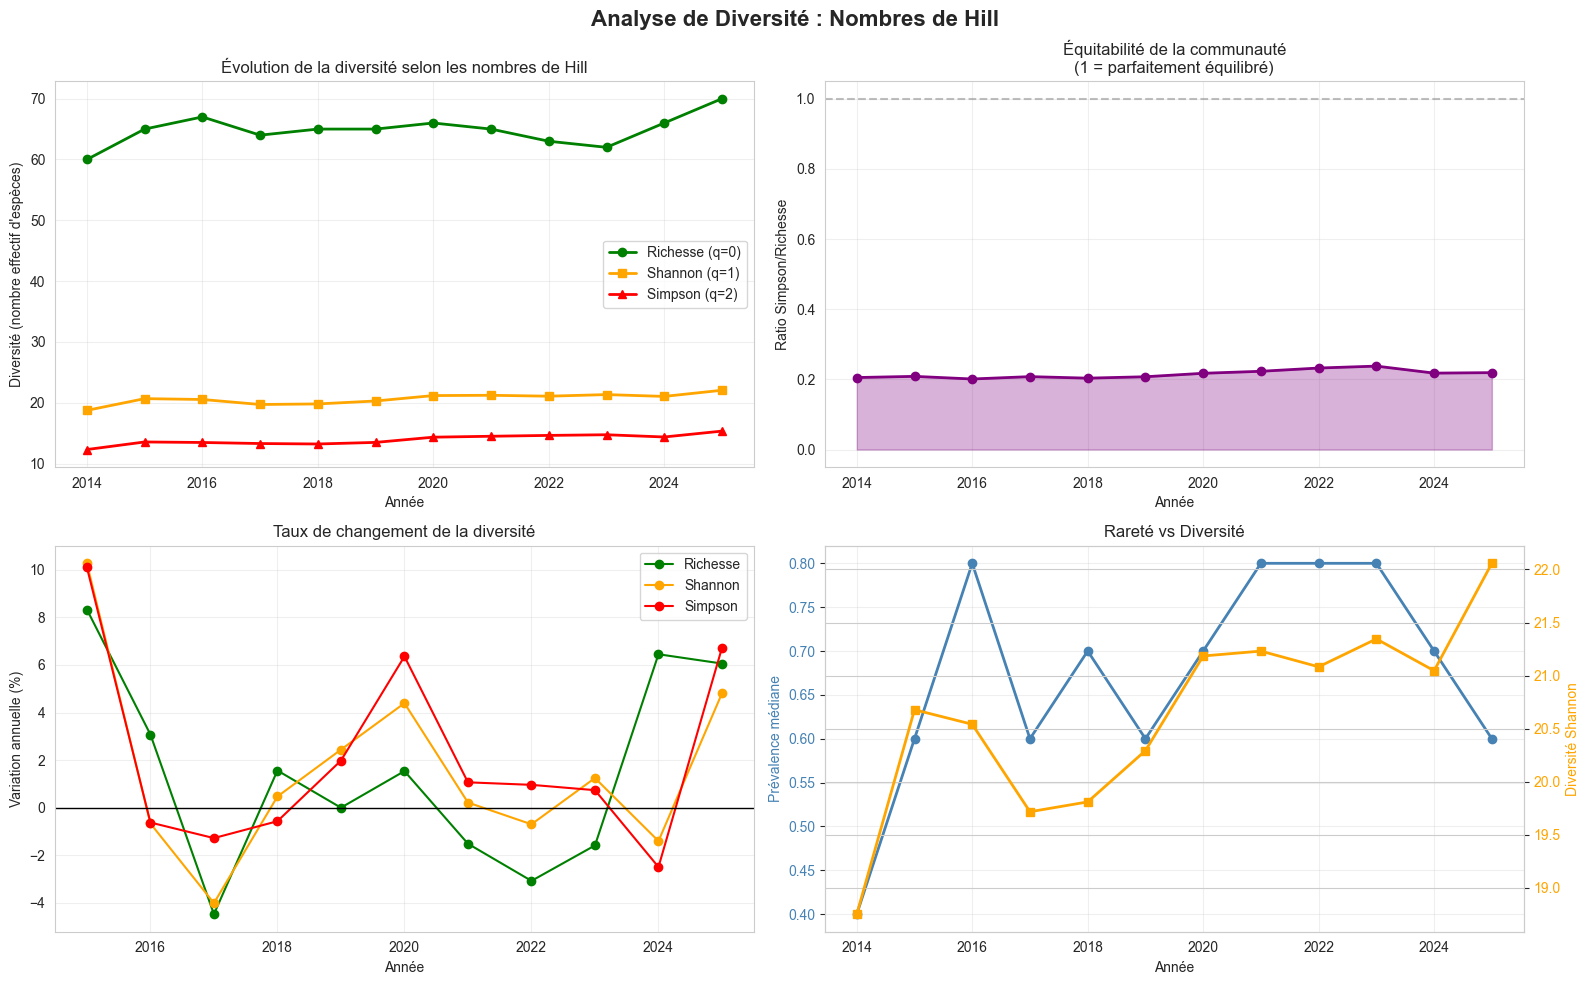


DIVERSITÉ (Nombres de Hill)
 year  richness_q0  shannon_q1  simpson_q2
 2014           60   18.751359   12.311638
 2015           65   20.678152   13.555765
 2016           67   20.540939   13.471237
 2017           64   19.716665   13.298914
 2018           65   19.809445   13.223279
 2019           65   20.292825   13.485039
 2020           66   21.184738   14.342749
 2021           65   21.230735   14.495717
 2022           63   21.082536   14.634968
 2023           62   21.345479   14.742739
 2024           66   21.045857   14.375019
 2025           70   22.058072   15.341566

TENDANCES
Richesse     : +0.28 espèces/an Hausse (R²=0.16, p=0.197)
Shannon      : +0.20 espèces/an Hausse (R²=0.66, p=0.001)
Simpson      : +0.21 espèces/an Hausse (R²=0.82, p=0.000)


In [41]:
from scipy.stats import entropy

def hill_number(counts, q):
    """Calcul des nombres de Hill"""
    counts = np.array(counts)
    counts = counts[counts > 0]  # Enlever les zéros
    p = counts / counts.sum()
    
    if q == 1:
        return np.exp(entropy(p))  # Shannon
    elif q == 0:
        return len(counts)  # Richesse
    else:
        return (np.sum(p ** q)) ** (1 / (1 - q))  # Hill général

# Calculer pour chaque année
hill_results = []
for year in df_bio['year'].unique():
    df_year = df_bio[df_bio['year'] == year]
    species_counts = df_year.groupby('species')['count'].sum()
    
    hill_results.append({
        'year': year,
        'richness_q0': hill_number(species_counts, q=0),
        'shannon_q1': hill_number(species_counts, q=1),
        'simpson_q2': hill_number(species_counts, q=2)
    })

df_hill = pd.DataFrame(hill_results).sort_values('year')

# === GRAPHIQUES ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Évolution des 3 indices de Hill
ax1 = axes[0, 0]
ax1.plot(df_hill['year'], df_hill['richness_q0'], marker='o', linewidth=2, 
        label='Richesse (q=0)', color='green')
ax1.plot(df_hill['year'], df_hill['shannon_q1'], marker='s', linewidth=2, 
        label='Shannon (q=1)', color='orange')
ax1.plot(df_hill['year'], df_hill['simpson_q2'], marker='^', linewidth=2, 
        label='Simpson (q=2)', color='red')
ax1.set_xlabel('Année')
ax1.set_ylabel('Diversité (nombre effectif d\'espèces)')
ax1.set_title('Évolution de la diversité selon les nombres de Hill')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Ratio Simpson/Richesse (équitabilité)
ax2 = axes[0, 1]
equitability = df_hill['simpson_q2'] / df_hill['richness_q0']
ax2.plot(df_hill['year'], equitability, marker='o', linewidth=2, color='purple')
ax2.fill_between(df_hill['year'], equitability, alpha=0.3, color='purple')
ax2.set_xlabel('Année')
ax2.set_ylabel('Ratio Simpson/Richesse')
ax2.set_title('Équitabilité de la communauté\n(1 = parfaitement équilibré)')
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax2.grid(alpha=0.3)

# 3. Taux de changement annuel
ax3 = axes[1, 0]
for col, label, color in [('richness_q0', 'Richesse', 'green'), 
                        ('shannon_q1', 'Shannon', 'orange'),
                        ('simpson_q2', 'Simpson', 'red')]:
    changes = df_hill[col].pct_change() * 100
    ax3.plot(df_hill['year'][1:], changes[1:], marker='o', label=label, color=color)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_xlabel('Année')
ax3.set_ylabel('Variation annuelle (%)')
ax3.set_title('Taux de changement de la diversité')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Comparaison Prévalence médiane vs Shannon
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()

# Prévalence médiane (axe gauche)
prev_med = df_rarete.groupby('year')['prevalence'].median()
ax4.plot(prev_med.index, prev_med.values, marker='o', linewidth=2, 
        color='steelblue', label='Prévalence médiane')
ax4.set_xlabel('Année')
ax4.set_ylabel('Prévalence médiane', color='steelblue')
ax4.tick_params(axis='y', labelcolor='steelblue')

# Shannon (axe droit)
ax4_twin.plot(df_hill['year'], df_hill['shannon_q1'], marker='s', linewidth=2, 
            color='orange', label='Shannon (q=1)')
ax4_twin.set_ylabel('Diversité Shannon', color='orange')
ax4_twin.tick_params(axis='y', labelcolor='orange')

ax4.set_title('Rareté vs Diversité')
ax4.grid(alpha=0.3)

plt.suptitle('Analyse de Diversité : Nombres de Hill', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# === STATISTIQUES ===
print(f"\nDIVERSITÉ (Nombres de Hill)")
print(f"{'='*60}")
print(df_hill.to_string(index=False))

print(f"\nTENDANCES")
print(f"{'='*60}")
for col, label in [('richness_q0', 'Richesse'), 
                    ('shannon_q1', 'Shannon'), 
                    ('simpson_q2', 'Simpson')]:
    from scipy.stats import linregress
    slope, _, r, p, _ = linregress(df_hill['year'], df_hill[col])
    trend = "Hausse" if slope > 0 else "Baisse"
    print(f"{label:12} : {slope:+.2f} espèces/an {trend} (R²={r**2:.2f}, p={p:.3f})")

In [42]:
print(f"\nINTERPRÉTATION DES RÉSULTATS")
print(f"{'='*60}")

# Comparer début et fin
premiere_annee = df_hill.iloc[0]
derniere_annee = df_hill.iloc[-1]

ratio_simpson_debut = premiere_annee['simpson_q2'] / premiere_annee['richness_q0']
ratio_simpson_fin = derniere_annee['simpson_q2'] / derniere_annee['richness_q0']

#En pourcentage
var_richesse = ((derniere_annee['richness_q0'] / premiere_annee['richness_q0']) - 1) * 100
var_shannon = ((derniere_annee['shannon_q1'] / premiere_annee['shannon_q1']) - 1) * 100
var_simpson = ((derniere_annee['simpson_q2'] / premiere_annee['simpson_q2']) - 1) * 100

# Tendances
from scipy.stats import linregress
pente_richesse, _, r2_rich, p_rich, _ = linregress(df_hill['year'], df_hill['richness_q0'])
pente_shannon, _, r2_shan, p_shan, _ = linregress(df_hill['year'], df_hill['shannon_q1'])
pente_simpson, _, r2_simp, p_simp, _ = linregress(df_hill['year'], df_hill['simpson_q2'])

print(f"\n1. EVOLUTION TEMPORELLE ({int(premiere_annee['year'])} - {int(derniere_annee['year'])})")
print("-" * 60)

if pente_richesse > 0 and pente_shannon > 0 and pente_simpson > 0:
    print("Tendance générale : Augmentation de la biodiversité")
    print(f"\nRichesse spécifique  : {premiere_annee['richness_q0']:.0f} -> {derniere_annee['richness_q0']:.0f} espèces ({var_richesse:+.1f}%)")
    print(f"Diversité Shannon    : {premiere_annee['shannon_q1']:.1f} -> {derniere_annee['shannon_q1']:.1f} ({var_shannon:+.1f}%)")
    print(f"Diversité Simpson    : {premiere_annee['simpson_q2']:.1f} -> {derniere_annee['simpson_q2']:.1f} ({var_simpson:+.1f}%)")
    
elif pente_richesse < 0 and pente_shannon < 0 and pente_simpson < 0:
    print("Tendance générale : Déclin de la biodiversité")
    print(f"\nPerte de richesse    : {pente_richesse:.2f} espèces/an (p={p_rich:.3f})")
    print(f"Perte de diversité   : Shannon {pente_shannon:.2f}/an, Simpson {pente_simpson:.2f}/an")
    
else:
    print("Tendance générale : Evolution contrastée")
    print(f"\nRichesse : {var_richesse:+.1f}% | Shannon : {var_shannon:+.1f}% | Simpson : {var_simpson:+.1f}%")

print(f"\n2. STRUCTURE DE LA COMMUNAUTE")
print("-" * 60)

n_dominantes = int(derniere_annee['simpson_q2'])
n_totales = int(derniere_annee['richness_q0'])

print(f"Nombre d'espèces total        : {n_totales}")
print(f"Espèces dominantes effectives : ~{n_dominantes}")
print(f"Ratio dominantes/total        : {ratio_simpson_fin:.2f}")

if ratio_simpson_fin > 0.7:
    diagnostic = "Communauté équilibrée - Faible dominance"
elif ratio_simpson_fin > 0.5:
    diagnostic = "Communauté moyennement équilibrée"
elif ratio_simpson_fin > 0.3:
    diagnostic = "Dominance modérée - Structure typique"
else:
    diagnostic = "Dominance forte - Concentration sur quelques espèces"

print(f"\nDiagnostic : {diagnostic}")

# Evolution de l'équitabilité
delta_ratio = ratio_simpson_fin - ratio_simpson_debut
if abs(delta_ratio) < 0.05:
    tendance_equit = "stable"
elif delta_ratio > 0:
    tendance_equit = "en amélioration"
else:
    tendance_equit = "en dégradation"

print(f"Evolution de l'équitabilité : {tendance_equit} (delta = {delta_ratio:+.3f})")

print(f"\n3. SIGNIFICATIVITE STATISTIQUE")
print("-" * 60)
print(f"Richesse  : R² = {r2_rich**2:.2f}, p-value = {p_rich:.4e} {'(significatif)' if p_rich < 0.05 else '(non significatif)'}")
print(f"Shannon   : R² = {r2_shan**2:.2f}, p-value = {p_shan:.4e} {'(significatif)' if p_shan < 0.05 else '(non significatif)'}")
print(f"Simpson   : R² = {r2_simp**2:.2f}, p-value = {p_simp:.4e} {'(significatif)' if p_simp < 0.05 else '(non significatif)'}")


INTERPRÉTATION DES RÉSULTATS

1. EVOLUTION TEMPORELLE (2014 - 2025)
------------------------------------------------------------
Tendance générale : Augmentation de la biodiversité

Richesse spécifique  : 60 -> 70 espèces (+16.7%)
Diversité Shannon    : 18.8 -> 22.1 (+17.6%)
Diversité Simpson    : 12.3 -> 15.3 (+24.6%)

2. STRUCTURE DE LA COMMUNAUTE
------------------------------------------------------------
Nombre d'espèces total        : 70
Espèces dominantes effectives : ~15
Ratio dominantes/total        : 0.22

Diagnostic : Dominance forte - Concentration sur quelques espèces
Evolution de l'équitabilité : stable (delta = +0.014)

3. SIGNIFICATIVITE STATISTIQUE
------------------------------------------------------------
Richesse  : R² = 0.16, p-value = 1.9669e-01 (non significatif)
Shannon   : R² = 0.66, p-value = 1.4150e-03 (significatif)
Simpson   : R² = 0.82, p-value = 4.7598e-05 (significatif)


# TODO Problème weights regarder avce le code généré en bas

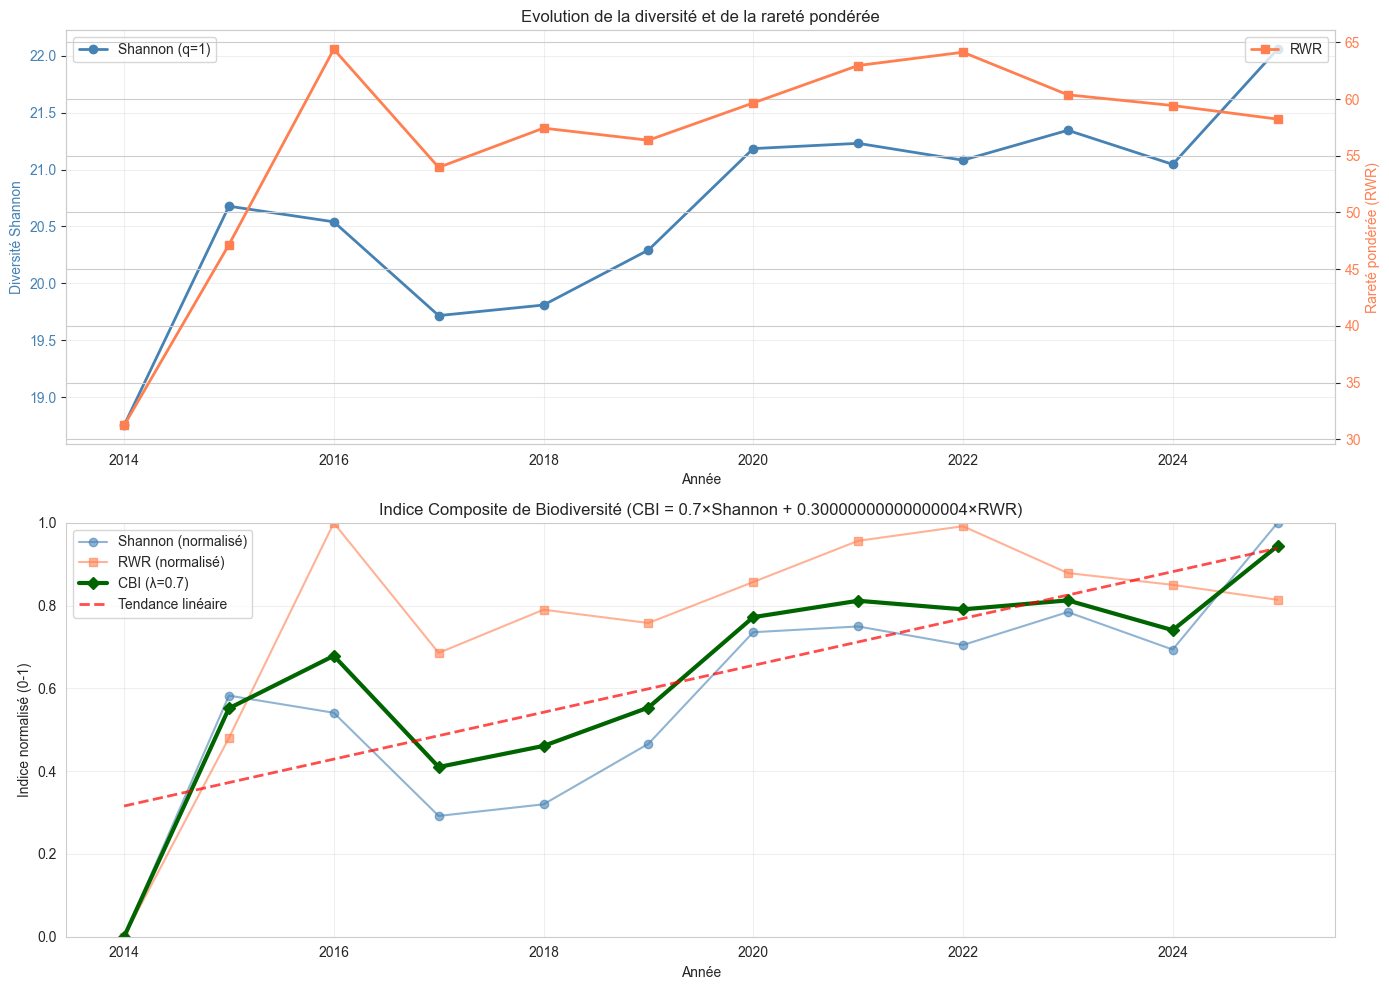

In [43]:
# Extraire les poids moyens par espèce (sur toutes les années où elle est présente)
poids_especes = (
        df_rarete[df_rarete['prevalence'] > 0]
        .groupby('species')['weight']
        .mean()
        .reset_index()
)

# Calcul de RARITY-WEIGHTED RICHNESS

# Joindre les poids aux observations
df_bio_weighted = df_bio.merge(poids_especes, on='species', how='left')

# Calculer par année (somme des poids des espèces présentes)
rwr_annuel = (
        df_bio_weighted[df_bio_weighted['count'] > 0]
        .groupby('year')['weight']
        .sum()
        .reset_index()
        .rename(columns={'weight': 'RWR'})
)

# Calcul de Composite Biodiversity Index en combinant Hill numbers et RWR
df_indices = df_hill.merge(rwr_annuel, on='year', how='left')

# Normaliser Shannon et RWR pour les rendre comparables
shannon_norm = (df_indices['shannon_q1'] - df_indices['shannon_q1'].min()) / \
                (df_indices['shannon_q1'].max() - df_indices['shannon_q1'].min())

rwr_norm = (df_indices['RWR'] - df_indices['RWR'].min()) / \
                (df_indices['RWR'].max() - df_indices['RWR'].min())

# Indice composite : 70% diversité + 30% rareté (Choix arbitraire)
lambda_weight = 0.7
df_indices['shannon_norm'] = shannon_norm
df_indices['rwr_norm'] = rwr_norm
df_indices['CBI'] = lambda_weight * shannon_norm + (1 - lambda_weight) * rwr_norm

# Graphiques
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Indices bruts
ax1 = axes[0]
ax1.plot(df_indices['year'], df_indices['shannon_q1'], 
        marker='o', linewidth=2, label='Shannon (q=1)', color='steelblue')
ax1.set_ylabel('Diversité Shannon', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(df_indices['year'], df_indices['RWR'], 
                marker='s', linewidth=2, label='RWR', color='coral')
ax1_twin.set_ylabel('Rareté pondérée (RWR)', color='coral')
ax1_twin.tick_params(axis='y', labelcolor='coral')

ax1.set_xlabel('Année')
ax1.set_title('Evolution de la diversité et de la rareté pondérée')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Indice composite normalisé
ax2 = axes[1]
ax2.plot(df_indices['year'], df_indices['shannon_norm'], 
        marker='o', linewidth=1.5, label='Shannon (normalisé)', 
        color='steelblue', alpha=0.6)
ax2.plot(df_indices['year'], df_indices['rwr_norm'], 
        marker='s', linewidth=1.5, label='RWR (normalisé)', 
        color='coral', alpha=0.6)
ax2.plot(df_indices['year'], df_indices['CBI'], 
        marker='D', linewidth=3, label=f'CBI (λ={lambda_weight})', 
        color='darkgreen')

# Ajouter régression linéaire sur CBI
X_reg = df_indices['year'].values
y_reg = df_indices['CBI'].values
z = np.polyfit(X_reg, y_reg, 1)
p = np.poly1d(z)
ax2.plot(X_reg, p(X_reg), '--', color='red', linewidth=2, 
        alpha=0.7, label='Tendance linéaire')

ax2.set_xlabel('Année')
ax2.set_ylabel('Indice normalisé (0-1)')
ax2.set_title(f'Indice Composite de Biodiversité (CBI = {lambda_weight}×Shannon + {1-lambda_weight}×RWR)')
ax2.legend(loc='best')
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [44]:
"""# Extraire les poids moyens par espèce (sur toutes les années où elle est présente)
poids_especes = (
        df_rarete[df_rarete['prevalence'] > 0]
        .groupby('species')['weight']
        .mean()
        .reset_index()
)

# Calcul de RARITY-WEIGHTED RICHNESS

# Joindre les poids aux observations
df_bio_weighted = df_bio.merge(poids_especes, on='species', how='left')

# Calculer par année (somme des poids des espèces présentes)
rwr_annuel = []

for year in sorted(df_rarete['year'].unique()):
        df_year_rarete = df_rarete[df_rarete['year'] == year]

        # Ne garder que les espèces présentes cette année (prevalence > 0)
        especes_presentes = df_year_rarete[df_year_rarete['prevalence'] > 0]

        # RWR = somme des poids des espèces présentes
        rwr_value = especes_presentes['weight'].sum()

        rwr_annuel.append({
                'year': year,
                'RWR': rwr_value
        })

df_rwr = pd.DataFrame(rwr_annuel)

# Calcul de Composite Biodiversity Index en combinant Hill numbers et RWR
df_indices = df_hill.merge(df_rwr, on='year', how='left')

# Normaliser pour le CBI
shannon_norm = (df_indices['shannon_q1'] - df_indices['shannon_q1'].min()) / \
                (df_indices['shannon_q1'].max() - df_indices['shannon_q1'].min())

rwr_norm = (df_indices['RWR'] - df_indices['RWR'].min()) / \
                (df_indices['RWR'].max() - df_indices['RWR'].min())

# Indice composite
lambda_weight = 0.7
df_indices['shannon_norm'] = shannon_norm
df_indices['rwr_norm'] = rwr_norm
df_indices['CBI'] = lambda_weight * shannon_norm + (1 - lambda_weight) * rwr_norm
# Graphiques
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Indices bruts
ax1 = axes[0]
ax1.plot(df_indices['year'], df_indices['shannon_q1'], 
        marker='o', linewidth=2, label='Shannon (q=1)', color='steelblue')
ax1.set_ylabel('Diversité Shannon', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(df_indices['year'], df_indices['RWR'], 
        marker='s', linewidth=2, label='RWR', color='coral')
ax1_twin.set_ylabel('Rareté pondérée (RWR)', color='coral')
ax1_twin.tick_params(axis='y', labelcolor='coral')

ax1.set_xlabel('Année')
ax1.set_title('Evolution de la diversité et de la rareté pondérée')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Indice composite normalisé
ax2 = axes[1]
ax2.plot(df_indices['year'], df_indices['shannon_norm'], 
        marker='o', linewidth=1.5, label='Shannon (normalisé)', 
        color='steelblue', alpha=0.6)
ax2.plot(df_indices['year'], df_indices['rwr_norm'], 
        marker='s', linewidth=1.5, label='RWR (normalisé)', 
        color='coral', alpha=0.6)
ax2.plot(df_indices['year'], df_indices['CBI'], 
        marker='D', linewidth=3, label=f'CBI (λ={lambda_weight})', 
        color='darkgreen')

# Ajouter régression linéaire sur CBI
X_reg = df_indices['year'].values
y_reg = df_indices['CBI'].values
z = np.polyfit(X_reg, y_reg, 1)
p = np.poly1d(z)
ax2.plot(X_reg, p(X_reg), '--', color='red', linewidth=2, 
        alpha=0.7, label='Tendance linéaire')

ax2.set_xlabel('Année')
ax2.set_ylabel('Indice normalisé (0-1)')
ax2.set_title(f'Indice Composite de Biodiversité (CBI = {lambda_weight}×Shannon + {1-lambda_weight}×RWR)')
ax2.legend(loc='best')
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()"""

"# Extraire les poids moyens par espèce (sur toutes les années où elle est présente)\npoids_especes = (\n        df_rarete[df_rarete['prevalence'] > 0]\n        .groupby('species')['weight']\n        .mean()\n        .reset_index()\n)\n\n# Calcul de RARITY-WEIGHTED RICHNESS\n\n# Joindre les poids aux observations\ndf_bio_weighted = df_bio.merge(poids_especes, on='species', how='left')\n\n# Calculer par année (somme des poids des espèces présentes)\nrwr_annuel = []\n\nfor year in sorted(df_rarete['year'].unique()):\n        df_year_rarete = df_rarete[df_rarete['year'] == year]\n\n        # Ne garder que les espèces présentes cette année (prevalence > 0)\n        especes_presentes = df_year_rarete[df_year_rarete['prevalence'] > 0]\n\n        # RWR = somme des poids des espèces présentes\n        rwr_value = especes_presentes['weight'].sum()\n\n        rwr_annuel.append({\n                'year': year,\n                'RWR': rwr_value\n        })\n\ndf_rwr = pd.DataFrame(rwr_annuel)\n\n#

In [45]:
import statsmodels.api as sm

X = sm.add_constant(df_indices['year'])
y = df_indices['CBI']

model = sm.OLS(y, X).fit()
print(model.summary())

trend = model.params['year']
if trend > 0:
    print(f"Tendance positive : biodiversité en hausse (+{trend:.3f} par an).")
else:
    print(f"Tendance négative : biodiversité en déclin ({trend:.3f} par an).")

                            OLS Regression Results                            
Dep. Variable:                    CBI   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     18.14
Date:                Wed, 05 Nov 2025   Prob (F-statistic):            0.00167
Time:                        20:44:28   Log-Likelihood:                 6.1302
No. Observations:                  12   AIC:                            -8.260
Df Residuals:                      10   BIC:                            -7.291
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -113.7615     26.858     -4.236      0.0

c:\Users\AMINE\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1806: UserWarning:

kurtosistest only valid for n>=20 ... continuing anyway, n=12



# 3.Species level evolution

## 3.1. Interesting subsets of birds

Nous sélectionnons les espèces selon trois critères complémentaires :
1. Importance écologique (forte abondance)
2. Préoccupation de conservation (statut menacé/migrateur)
3. Tendances temporelles distinctives (augmentation/diminution significative)

In [46]:
# --- CALCULS PRÉPARATOIRES ---

# Filtrer pour la période d'analyse (2014-2025)
df_species_analysis = df_full[(df_full['year'] >= 2014) & (df_full['year'] <= 2025)].copy()
df_species_analysis['individual_count'] = df_species_analysis['auditory_visual_with_flight_total'].fillna(0)

# Calculer des statistiques complètes sur les espèces
species_stats = df_species_analysis.groupby('species').agg({
    'individual_count': ['sum', 'mean', 'std', 'count'],
    'transect': 'nunique',
    'year': ['min', 'max', 'nunique']
}).round(2)

species_stats.columns = ['total_count', 'mean_count', 'std_count', 'n_observations',
                         'n_transects', 'first_year', 'last_year', 'n_years']

# Add conservation status
if 'status' in df_species_analysis.columns:
    species_status_map = df_species_analysis.groupby('species')['status'].first()
    species_stats['status'] = species_stats.index.map(species_status_map)

# Calculer les tendances temporelles
def calculate_temporal_trend(species_name, df):
    """Calculate linear trend for a species over time."""
    species_data = df[df['species'] == species_name].copy()
    yearly = species_data.groupby('year')['individual_count'].sum().reset_index()
    
    if len(yearly) < 3:
        return {'slope': 0, 'r_squared': 0, 'p_value': 1, 'n_years': len(yearly)}
    
    x = yearly['year'].values
    y = yearly['individual_count'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    return {
        'slope': slope,
        'r_squared': r_value**2,
        'p_value': p_value,
        'n_years': len(yearly)
    }

# Calculer les tendances pour toutes les espèces avec des données suffisantes
all_species = species_stats.index.tolist()
trends = {sp: calculate_temporal_trend(sp, df_species_analysis) for sp in all_species}
trends_df = pd.DataFrame(trends).T


✓ Critère 1 : Espèces à forte abondance


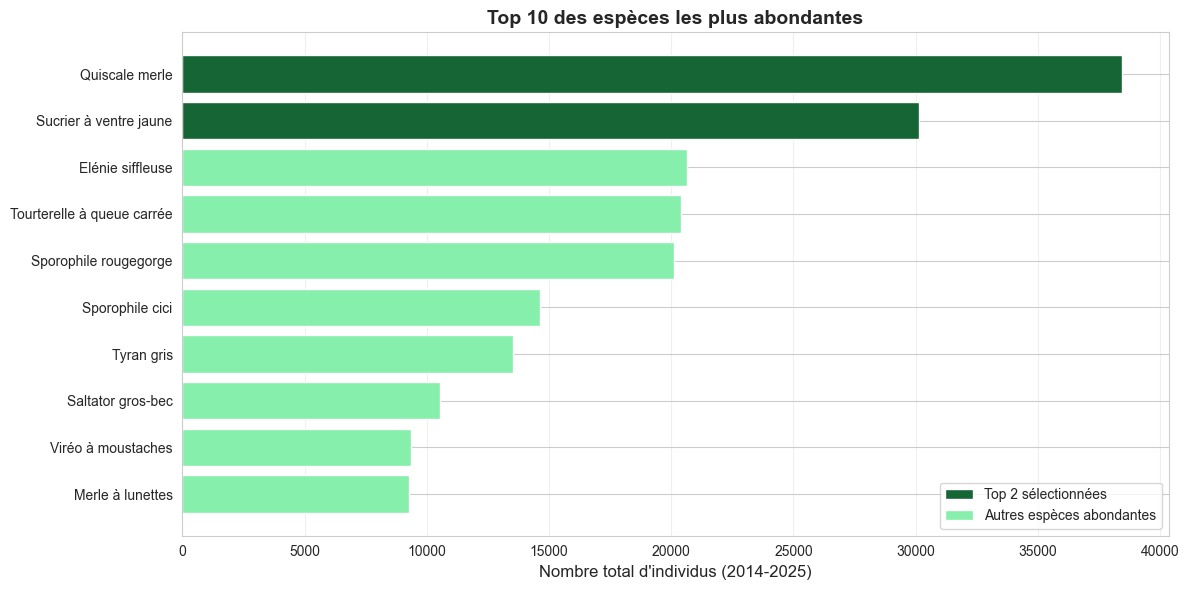


Espèces sélectionnées pour analyse détaillée:
  - Quiscale merle
  - Sucrier à ventre jaune


In [47]:
#critére 1 : Espèces à forte abondance
print("✓ Critère 1 : Espèces à forte abondance")

# Sélectionner les 10 espèces les plus abondantes
abundant_species = species_stats.nlargest(10, 'total_count')

# Sélectionner les 2 premières pour l'analyse détaillée
abundant_species_selected = abundant_species.index[:2].tolist()

# Visualisation avec code couleur
fig, ax = plt.subplots(figsize=(12, 6))

# Inverser l'ordre pour affichage du haut vers le bas
y_positions = range(len(abundant_species))[::-1]

# Couleurs : vert foncé pour les 2 sélectionnées, vert clair pour les autres
colors_abundance = np.array(['#166534' if i < 2 else '#86efac' for i in range(len(abundant_species))])

bars = ax.barh(y_positions, abundant_species['total_count'], color=colors_abundance)
ax.set_yticks(y_positions)
ax.set_yticklabels(abundant_species.index)
ax.set_xlabel('Nombre total d\'individus (2014-2025)', fontsize=12)
ax.set_title('Top 10 des espèces les plus abondantes', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Légende pour indiquer les espèces sélectionnées
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#166534', label='Top 2 sélectionnées'),
                   Patch(facecolor='#86efac', label='Autres espèces abondantes')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print(f"\nEspèces sélectionnées pour analyse détaillée:")
for sp in abundant_species_selected:
    print(f"  - {sp}")

CRITÈRE 2: ESPÈCES DE PRÉOCCUPATION POUR LA CONSERVATION


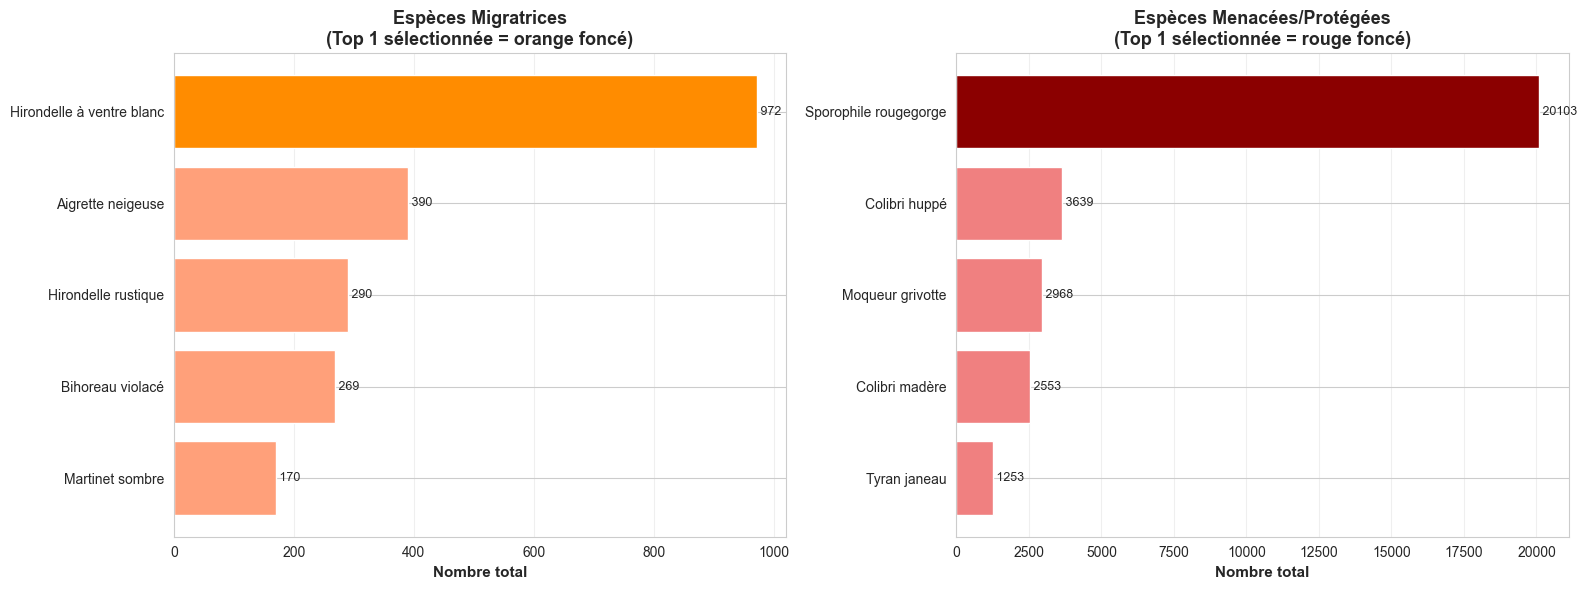


Espèces sélectionnées pour analyse détaillée:
  - Hirondelle à ventre blanc
  - Sporophile rougegorge


In [48]:
# Critere 2: Espèces de préoccupation pour la conservation
print("CRITÈRE 2: ESPÈCES DE PRÉOCCUPATION POUR LA CONSERVATION")

conservation_species = []

if 'status' in species_stats.columns:
    # Préparer les données
    migratory = species_stats[
        (species_stats['status'] == 'Migrateur') & 
        (species_stats['total_count'] > 50)
    ].nlargest(5, 'total_count')
    
    endangered_keywords = ['Endémique', 'Protégé', 'Vulnérable']
    endangered = species_stats[
        species_stats['status'].str.contains('|'.join(endangered_keywords), na=False, case=False)
    ].nlargest(5, 'total_count')
    
    # Graphique à 2 panneaux
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Panneau 1 : Espèces migratrices
    if len(migratory) > 0:
        colors1 = ['darkorange' if i < 1 else 'lightsalmon' for i in range(len(migratory))]
        y_pos1 = range(len(migratory))[::-1]
        ax1.barh(y_pos1, migratory['total_count'], color=colors1)
        ax1.set_yticks(y_pos1)
        ax1.set_yticklabels([sp[:35] for sp in migratory.index], fontsize=10)
        ax1.set_xlabel('Nombre total', fontsize=11, fontweight='bold')
        ax1.set_title('Espèces Migratrices\n(Top 1 sélectionnée = orange foncé)', 
                      fontsize=13, fontweight='bold')
        ax1.grid(axis='x', alpha=0.3)
        
        for i, (idx, row) in enumerate(migratory.iterrows()):
            ax1.text(row['total_count'], len(migratory) - 1 - i, f" {int(row['total_count'])}", 
                    va='center', fontsize=9)
        
        conservation_species.extend(migratory.head(1).index.tolist())
    
    # Panneau 2 : Espèces menacées
    if len(endangered) > 0:
        colors2 = ['darkred' if i < 1 else 'lightcoral' for i in range(len(endangered))]
        y_pos2 = range(len(endangered))[::-1]
        ax2.barh(y_pos2, endangered['total_count'], color=colors2)
        ax2.set_yticks(y_pos2)
        ax2.set_yticklabels([sp[:35] for sp in endangered.index], fontsize=10)
        ax2.set_xlabel('Nombre total', fontsize=11, fontweight='bold')
        ax2.set_title('Espèces Menacées/Protégées\n(Top 1 sélectionnée = rouge foncé)', 
                      fontsize=13, fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        
        for i, (idx, row) in enumerate(endangered.iterrows()):
            ax2.text(row['total_count'], len(endangered) - 1 - i, f" {int(row['total_count'])}", 
                    va='center', fontsize=9)
        
        for sp in endangered.head(1).index:
            if sp not in conservation_species:
                conservation_species.append(sp)
    
    plt.tight_layout()
    plt.show()
    
print(f"\nEspèces sélectionnées pour analyse détaillée:")
for sp in conservation_species:
    print(f"  - {sp}")

✓ Critère 3 : Tendances temporelles distinctives
Nombre d'espèces observées récemment (2023-2025): 74
Espèces récentes en augmentation: 5
Espèces récentes en diminution: 5


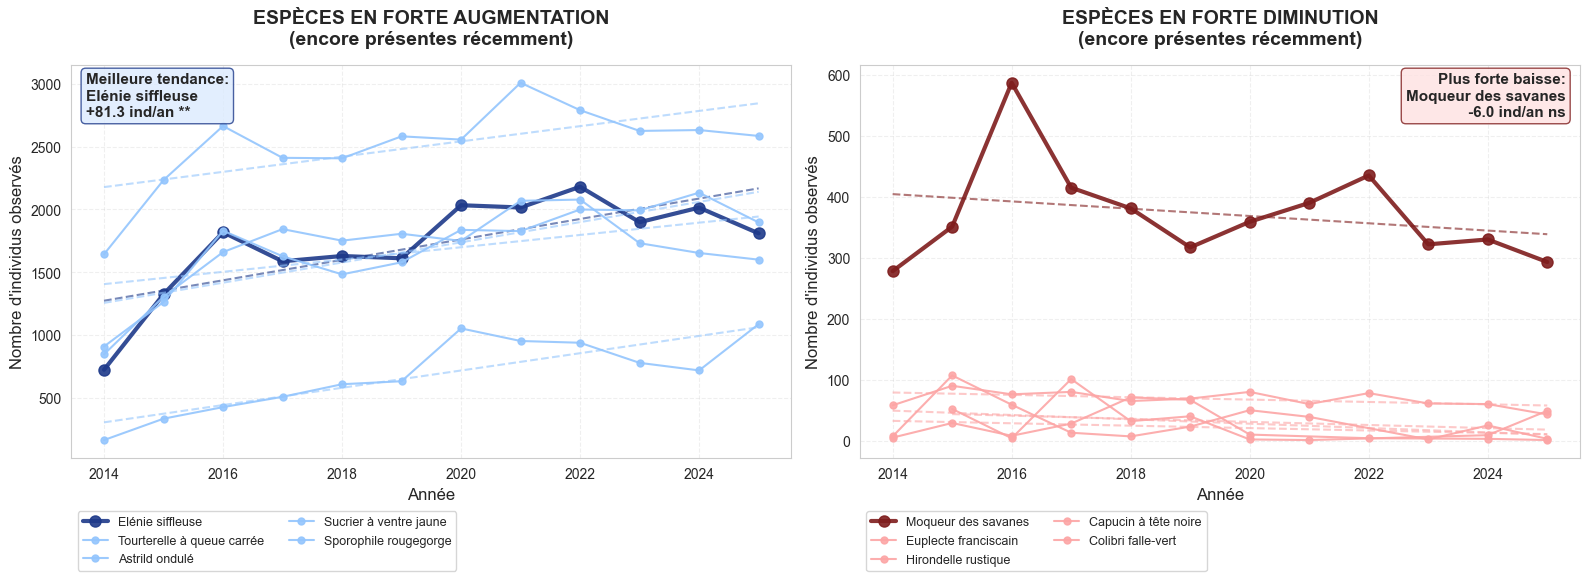


Espèces sélectionnées pour analyse détaillée:
  - Elénie siffleuse
  - Moqueur des savanes


In [49]:
# Critère 3 : Tendances temporelles distinctives
print("✓ Critère 3 : Tendances temporelles distinctives")

# Identifier les espèces qui existent encore aujourd'hui (présentes dans les années récentes)
# On considère qu'une espèce existe encore si elle a été observée dans les 3 dernières années
recent_years = df_species_analysis[df_species_analysis['year'] >= 2023]
recent_species = recent_years['species'].unique()

print(f"Nombre d'espèces observées récemment (2023-2025): {len(recent_species)}")

# Filtrer les tendances pour ne garder que les espèces encore existantes
trends_recent = trends_df[trends_df.index.isin(recent_species)]

# Séparer les tendances croissantes et décroissantes (parmi les espèces récentes)
increasing = trends_recent[trends_recent['slope'] > 0].nlargest(5, 'slope')
decreasing = trends_recent[trends_recent['slope'] < 0].nsmallest(5, 'slope')

print(f"Espèces récentes en augmentation: {len(increasing)}")
print(f"Espèces récentes en diminution: {len(decreasing)}")

# Sélection : 1 meilleure croissante + 1 pire décroissante
if len(increasing) > 0 and len(decreasing) > 0:
    trend_species = [
        increasing.index[0],  # Meilleure tendance croissante
        decreasing.index[0]   # Pire tendance décroissante
    ]
else:
    trend_species = []
    print("⚠️ Attention: Pas assez d'espèces récentes avec des tendances marquées")

# Créer la figure avec deux graphiques côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique gauche : ESPÈCES EN FORTE AUGMENTATION ---
ax1.set_title('ESPÈCES EN FORTE AUGMENTATION\n(encore présentes récemment)', fontsize=14, fontweight='bold', pad=15)

if len(increasing) > 0:
    # Pour chaque espèce, récupérer les données temporelles réelles
    for i, (sp, row) in enumerate(increasing.iterrows()):
        species_data = df_species_analysis[df_species_analysis['species'] == sp]
        yearly = species_data.groupby('year')['individual_count'].sum().reset_index()
        
        # Couleur et style selon le rang
        if i == 0:
            color = '#1e3a8a'  # Bleu foncé pour la meilleure
            linewidth = 3
            marker = 'o'
            markersize = 8
        else:
            color = '#93c5fd'  # Bleu clair pour les autres
            linewidth = 1.5
            marker = 'o'
            markersize = 5
        
        # Tracer les données réelles
        ax1.plot(yearly['year'], yearly['individual_count'], 
                color=color, linewidth=linewidth, marker=marker, markersize=markersize,
                label=sp, alpha=0.9)
        
        # Ajouter la ligne de tendance (en pointillés)
        z = np.polyfit(yearly['year'], yearly['individual_count'], 1)
        p = np.poly1d(z)
        ax1.plot(yearly['year'], p(yearly['year']), '--', color=color, linewidth=1.5, alpha=0.6)

    # Annoter la meilleure espèce
    best_sp = increasing.index[0]
    best_slope = increasing.loc[best_sp, 'slope']
    p_val = increasing.loc[best_sp, 'p_value']
    if p_val < 0.001:
        p_sig = '***'
    elif p_val < 0.01:
        p_sig = '**'
    elif p_val < 0.05:
        p_sig = '*'
    else:
        p_sig = 'ns'

    # Placer l'annotation en haut à gauche du graphique
    ax1.text(0.02, 0.98, f'Meilleure tendance:\n{best_sp}\n+{best_slope:.1f} ind/an {p_sig}',
            transform=ax1.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='#dbeafe', alpha=0.8, edgecolor='#1e3a8a'))

    ax1.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=2, fontsize=9)
else:
    ax1.text(0.5, 0.5, 'Aucune espèce récente en augmentation', 
            transform=ax1.transAxes, ha='center', va='center', fontsize=12)

ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Nombre d\'individus observés', fontsize=12)
ax1.grid(True, alpha=0.3, linestyle='--')

# --- Graphique droite : ESPÈCES EN FORTE DIMINUTION ---
ax2.set_title('ESPÈCES EN FORTE DIMINUTION\n(encore présentes récemment)', fontsize=14, fontweight='bold', pad=15)

if len(decreasing) > 0:
    # Pour chaque espèce, récupérer les données temporelles réelles
    for i, (sp, row) in enumerate(decreasing.iterrows()):
        species_data = df_species_analysis[df_species_analysis['species'] == sp]
        yearly = species_data.groupby('year')['individual_count'].sum().reset_index()
        
        # Couleur et style selon le rang
        if i == 0:
            color = '#7f1d1d'  # Rouge foncé pour la pire
            linewidth = 3
            marker = 'o'
            markersize = 8
        else:
            color = '#fca5a5'  # Rouge clair pour les autres
            linewidth = 1.5
            marker = 'o'
            markersize = 5
        
        # Tracer les données réelles
        ax2.plot(yearly['year'], yearly['individual_count'], 
                color=color, linewidth=linewidth, marker=marker, markersize=markersize,
                label=sp, alpha=0.9)
        
        # Ajouter la ligne de tendance (en pointillés)
        z = np.polyfit(yearly['year'], yearly['individual_count'], 1)
        p = np.poly1d(z)
        ax2.plot(yearly['year'], p(yearly['year']), '--', color=color, linewidth=1.5, alpha=0.6)

    # Annoter la pire espèce
    worst_sp = decreasing.index[0]
    worst_slope = decreasing.loc[worst_sp, 'slope']
    p_val = decreasing.loc[worst_sp, 'p_value']
    if p_val < 0.001:
        p_sig = '***'
    elif p_val < 0.01:
        p_sig = '**'
    elif p_val < 0.05:
        p_sig = '*'
    else:
        p_sig = 'ns'

    # Placer l'annotation en haut à droite du graphique
    ax2.text(0.98, 0.98, f'Plus forte baisse:\n{worst_sp}\n{worst_slope:.1f} ind/an {p_sig}',
            transform=ax2.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='#fee2e2', alpha=0.8, edgecolor='#7f1d1d'))

    ax2.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=2, fontsize=9)
else:
    ax2.text(0.5, 0.5, 'Aucune espèce récente en diminution', 
            transform=ax2.transAxes, ha='center', va='center', fontsize=12)

ax2.set_xlabel('Année', fontsize=12)
ax2.set_ylabel('Nombre d\'individus observés', fontsize=12)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

if len(trend_species) > 0:
    print(f"\nEspèces sélectionnées pour analyse détaillée:")
    for sp in trend_species:
        print(f"  - {sp}")

## 3.2 Analysis of species previously selected

### Résumé de l'analyse

Dans cette section, nous allons réalisé une **analyse statistique approfondie** des tendances temporelles pour les espèces sélectionnées :

**Méthodologie :**
- **Régression linéaire simple** pour estimer la tendance annuelle (pente = changement moyen d'individus/an)
- **Intervalles de confiance à 95%** calculés par deux méthodes :
  - Approche **paramétrique** (basée sur le modèle OLS)
  - Approche **bootstrap non-paramétrique** (1000 rééchantillonnages) pour valider la robustesse
- Tests de significativité statistique (p-value < 0.05)

**Visualisations produites :**
1. **Graphiques individuels** pour chaque espèce montrant :
   - L'évolution temporelle des comptages avec la ligne de tendance et les bandes de confiance
   - La distribution bootstrap des pentes avec comparaison des IC paramétriques vs bootstrap
   
2. **Tableau récapitulatif** présentant pour toutes les espèces :
   - La catégorie (abondante, conservation, tendance marquée)
   - La pente estimée et son intervalle de confiance
   - Le R² (qualité de l'ajustement) et la p-value (significativité)
   
3. **Forest plot comparatif** permettant de :
   - Visualiser simultanément toutes les tendances avec leurs incertitudes
   - Identifier rapidement les espèces en hausse vs en baisse significative
   - Comparer les catégories d'espèces (code couleur)

**Interprétation :**
- Les espèces avec **p < 0.05** montrent des tendances temporelles statistiquement significatives
- La **concordance entre IC paramétriques et bootstrap** renforce la fiabilité des estimations
- Le **R²** indique la qualité de l'ajustement linéaire (>0.5 = bon ajustement)

In [ ]:
species_selected = set(abundant_species_selected) | set(conservation_species) | set(trend_species)

In [ ]:
from sklearn.utils import resample

def analyze_species_detailed(species_name, df_data):
    """Analyse temporelle d'une espèce avec régression linéaire et IC."""
    sp_data = df_data[df_data['species'] == species_name].copy()
    yearly = sp_data.groupby('year')['individual_count'].sum().reset_index()
    
    X = yearly['year'].values
    y = yearly['individual_count'].values
    
    # Régression linéaire
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)
    
    # IC avec statsmodels
    X_sm = sm.add_constant(X)
    model = sm.OLS(y, X_sm).fit()
    ci_slope = model.conf_int(alpha=0.05)[1]
    predictions = model.get_prediction(X_sm)
    pred_summary = predictions.summary_frame(alpha=0.05)
    
    # Bootstrap pour validation
    bootstrap_slopes = []
    np.random.seed(42)
    for _ in range(1000):
        indices = resample(range(len(X)), replace=True)
        bs_slope = stats.linregress(X[indices], y[indices])[0]
        bootstrap_slopes.append(bs_slope)
    ci_boot = np.percentile(bootstrap_slopes, [2.5, 97.5])
    
    return {
        'species': species_name,
        'data': yearly,
        'X': X,
        'y': y,
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'ci_slope': ci_slope,
        'ci_boot': ci_boot,
        'predictions': pred_summary,
        'fitted_values': model.fittedvalues,
        'model': model,
        'bootstrap_slopes': bootstrap_slopes
    }

# Analyser toutes les espèces sélectionnées
results = {}
for species in species_selected:
    result = analyze_species_detailed(species, df_species_analysis)
    if result is not None:
        results[species] = result

print(f"Espèces analysées: {len(results)}")
for sp in results.keys():
    print(f"  - {sp}")

Espèces analysées: 6
  - Elénie siffleuse
  - Sucrier à ventre jaune
  - Moqueur des savanes
  - Quiscale merle
  - Sporophile rougegorge
  - Hirondelle à ventre blanc


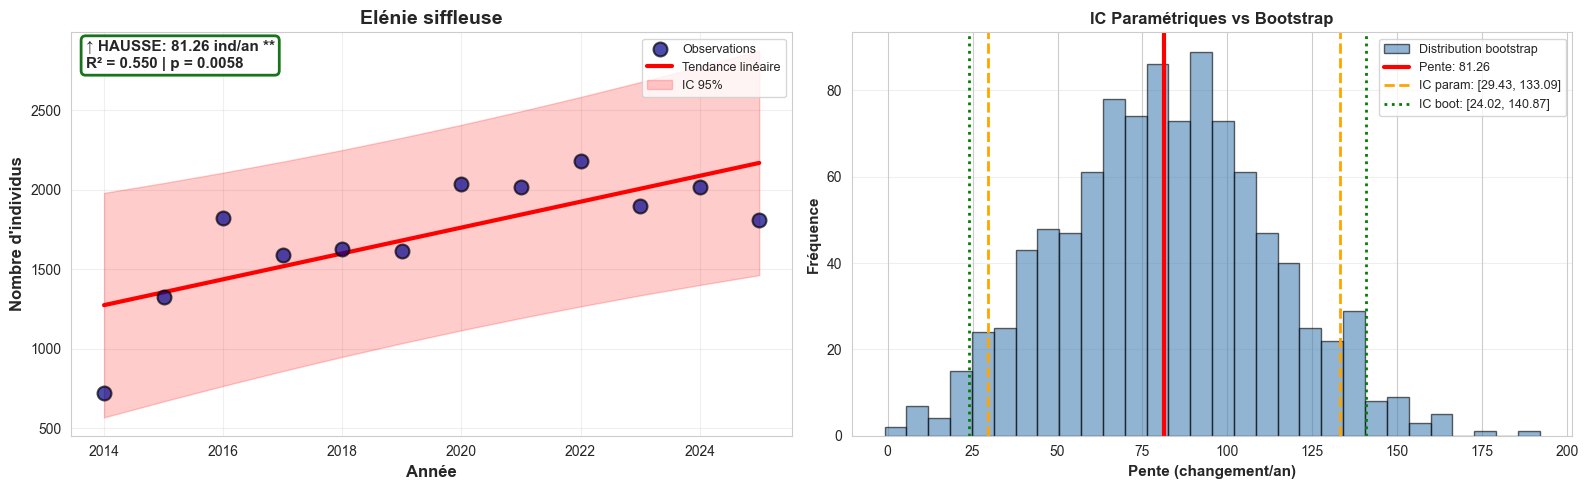

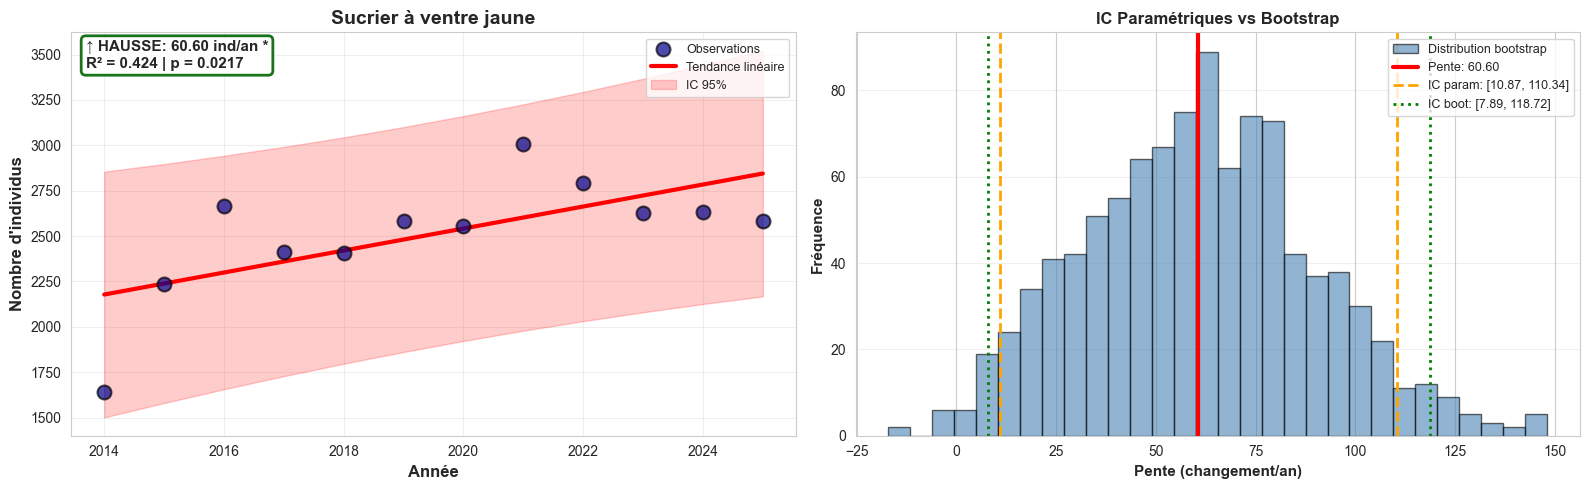

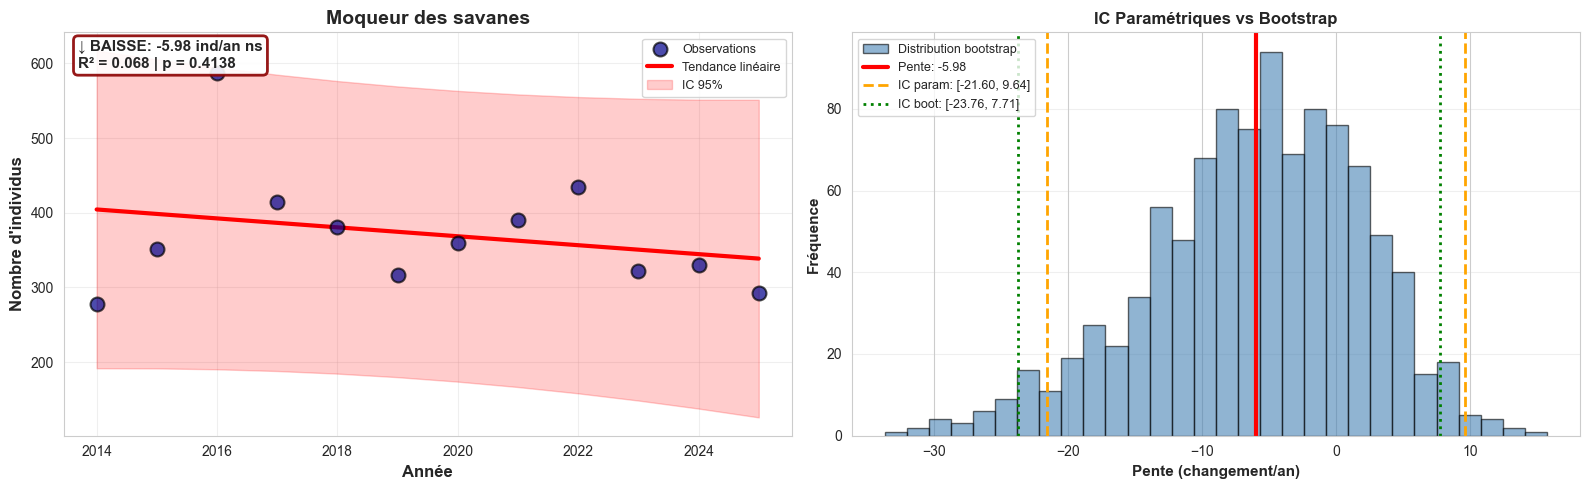

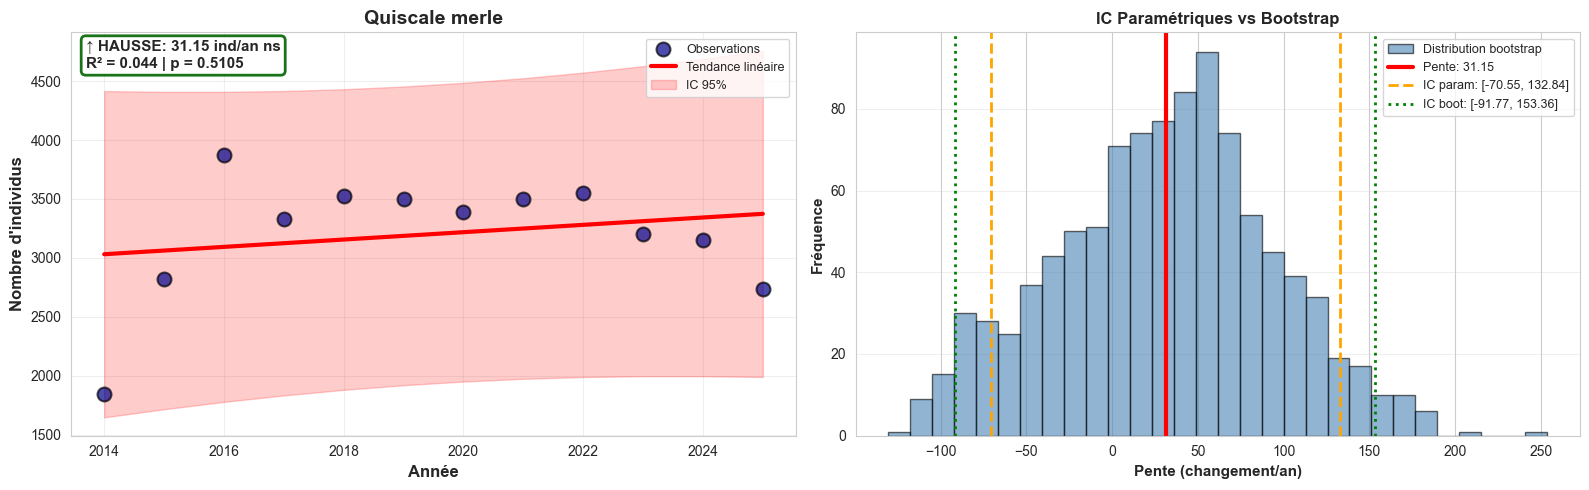

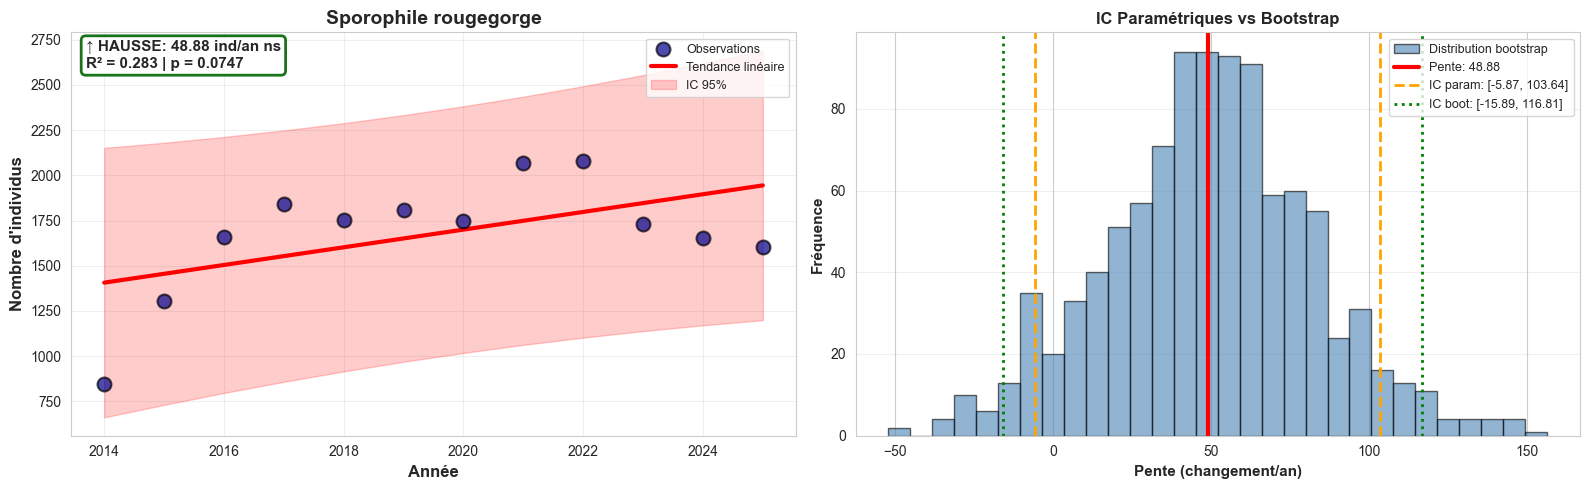

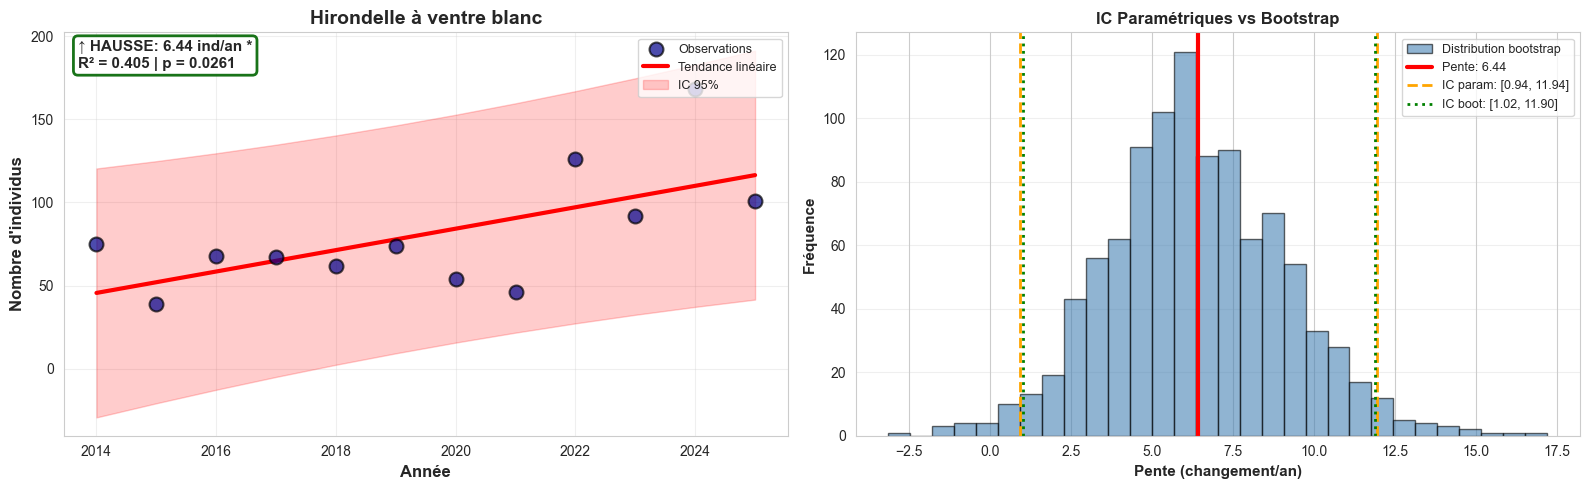

In [ ]:
# Visualiser l'évolution temporelle de chaque espèce
for species_name, result in results.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    X = result['X']
    y = result['y']
    pred_summary = result['predictions']
    
    # Graphique 1: Évolution temporelle avec IC
    ax1.scatter(X, y, s=100, alpha=0.7, color='darkblue', edgecolors='black', 
                linewidth=1.5, label='Observations', zorder=3)
    ax1.plot(X, result['fitted_values'], color='red', linewidth=3, 
             label='Tendance linéaire', zorder=2)
    ax1.fill_between(X, pred_summary['obs_ci_lower'], pred_summary['obs_ci_upper'],
                     alpha=0.2, color='red', label='IC 95%')
    
    slope = result['slope']
    p_val = result['p_value']
    r_sq = result['r_squared']
    ci_param = result['ci_slope']
    
    sig_stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    trend_text = f"{'↑ HAUSSE' if slope > 0 else '↓ BAISSE'}: {slope:.2f} ind/an {sig_stars}\nR² = {r_sq:.3f} | p = {p_val:.4f}"
    trend_color = 'darkgreen' if slope > 0 else 'darkred'
    
    ax1.text(0.02, 0.98, trend_text, transform=ax1.transAxes, fontsize=11, fontweight='bold',
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', 
             alpha=0.9, edgecolor=trend_color, linewidth=2))
    
    ax1.set_xlabel('Année', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Nombre d\'individus', fontsize=12, fontweight='bold')
    ax1.set_title(f'{species_name}', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Graphique 2: Comparaison IC paramétriques vs bootstrap
    ci_boot = result['ci_boot']
    bootstrap_slopes = result['bootstrap_slopes']
    
    ax2.hist(bootstrap_slopes, bins=30, alpha=0.6, color='steelblue', 
             edgecolor='black', label='Distribution bootstrap')
    ax2.axvline(slope, color='red', linewidth=3, label=f'Pente: {slope:.2f}')
    ax2.axvline(ci_param[0], color='orange', linestyle='--', linewidth=2)
    ax2.axvline(ci_param[1], color='orange', linestyle='--', linewidth=2, 
                label=f'IC param: [{ci_param[0]:.2f}, {ci_param[1]:.2f}]')
    ax2.axvline(ci_boot[0], color='green', linestyle=':', linewidth=2)
    ax2.axvline(ci_boot[1], color='green', linestyle=':', linewidth=2,
                label=f'IC boot: [{ci_boot[0]:.2f}, {ci_boot[1]:.2f}]')
    
    ax2.set_xlabel('Pente (changement/an)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Fréquence', fontsize=11, fontweight='bold')
    ax2.set_title('IC Paramétriques vs Bootstrap', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Tableau récapitulatif
summary_data = []
for species_name, result in results.items():
    if species_name in abundant_species_selected:
        category = "Abondante"
    elif species_name in conservation_species:
        category = "Conservation"
    elif species_name in trend_species:
        category = "Tendance marquée"
    else:
        category = "Autre"
    
    slope = result['slope']
    p_val = result['p_value']
    
    summary_data.append({
        'Espèce': species_name[:40],
        'Catégorie': category,
        'Pente': f"{slope:.2f}",
        'IC 95%': f"[{result['ci_slope'][0]:.2f}, {result['ci_slope'][1]:.2f}]",
        'R²': f"{result['r_squared']:.3f}",
        'p-value': f"{p_val:.4f}",
        'Significatif': '✓' if p_val < 0.05 else '✗'
    })

df_summary = pd.DataFrame(summary_data)
print("\nRÉCAPITULATIF DES TENDANCES TEMPORELLES")
print("="*100)
print(df_summary.to_string(index=False))
print("="*100)


RÉCAPITULATIF DES TENDANCES TEMPORELLES
                   Espèce        Catégorie Pente           IC 95%    R² p-value Significatif
         Elénie siffleuse Tendance marquée 81.26  [29.43, 133.09] 0.550  0.0058            ✓
   Sucrier à ventre jaune        Abondante 60.60  [10.87, 110.34] 0.424  0.0217            ✓
      Moqueur des savanes Tendance marquée -5.98   [-21.60, 9.64] 0.068  0.4138            ✗
           Quiscale merle        Abondante 31.15 [-70.55, 132.84] 0.044  0.5105            ✗
    Sporophile rougegorge     Conservation 48.88  [-5.87, 103.64] 0.283  0.0747            ✗
Hirondelle à ventre blanc     Conservation  6.44    [0.94, 11.94] 0.405  0.0261            ✓


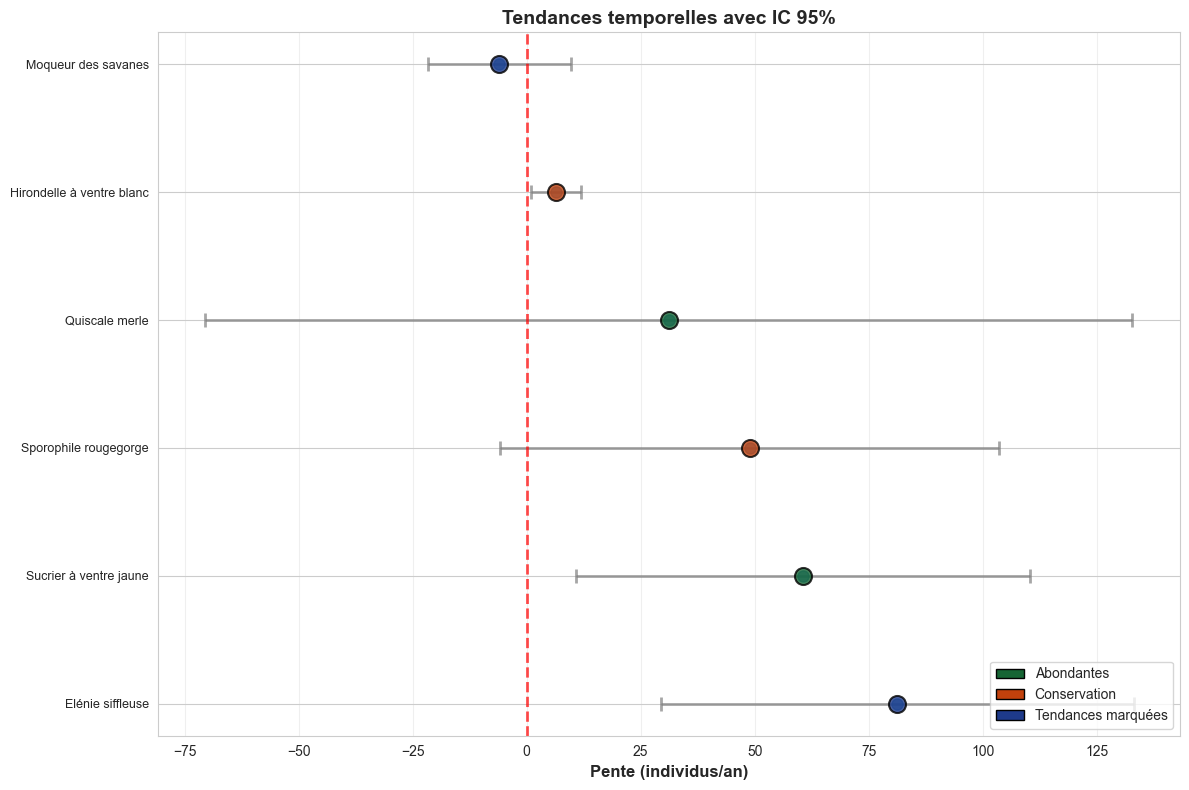

In [ ]:
# Forest plot des pentes avec IC
fig, ax = plt.subplots(figsize=(12, max(8, len(results) * 0.6)))

species_list = []
slopes = []
ci_lows = []
ci_highs = []
colors = []

for species_name, result in results.items():
    species_list.append(species_name[:35])
    slopes.append(result['slope'])
    ci_lows.append(result['ci_slope'][0])
    ci_highs.append(result['ci_slope'][1])
    
    if species_name in abundant_species_selected:
        colors.append('#166534')
    elif species_name in conservation_species:
        colors.append('#c2410c')
    elif species_name in trend_species:
        colors.append('#1e3a8a')
    else:
        colors.append('gray')

# Trier par pente
sorted_indices = np.argsort(slopes)[::-1]
species_list = [species_list[i] for i in sorted_indices]
slopes = [slopes[i] for i in sorted_indices]
ci_lows = [ci_lows[i] for i in sorted_indices]
ci_highs = [ci_highs[i] for i in sorted_indices]
colors = [colors[i] for i in sorted_indices]

errors_low = [slopes[i] - ci_lows[i] for i in range(len(slopes))]
errors_high = [ci_highs[i] - slopes[i] for i in range(len(slopes))]
y_positions = range(len(species_list))

ax.errorbar(slopes, y_positions, xerr=[errors_low, errors_high],
           fmt='o', markersize=8, capsize=5, capthick=2,
           ecolor='gray', elinewidth=2, alpha=0.7)

for i, (slope, y, color) in enumerate(zip(slopes, y_positions, colors)):
    ax.scatter(slope, y, s=150, color=color, edgecolors='black', 
              linewidth=1.5, zorder=3, alpha=0.8)

ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_yticks(y_positions)
ax.set_yticklabels(species_list, fontsize=9)
ax.set_xlabel('Pente (individus/an)', fontsize=12, fontweight='bold')
ax.set_title('Tendances temporelles avec IC 95%', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#166534', edgecolor='black', label='Abondantes'),
    Patch(facecolor='#c2410c', edgecolor='black', label='Conservation'),
    Patch(facecolor='#1e3a8a', edgecolor='black', label='Tendances marquées')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## 3.3 Potential ecological reasons behind the previously observed patterns